# D10 — Gêmeo Digital de Ponta a Ponta

## Aula final integradora do módulo — UNIMED SP

**Prof. Pedro | Simulação em Serviços de Saúde**

---

### 📋 Papel desta aula no módulo

Este notebook é a **aula final de integração** do módulo de gêmeos digitais. Os fundamentos de SimPy já foram trabalhados na trilha `D10/simpy_exemplos/`; aqui, o foco muda de **aprender blocos isolados** para **integrar dados, calibração, simulação, validação, atualização, predição e decisão** em um único caso aplicado.

> 💡 **O que é um Gêmeo Digital?** É um modelo computacional que replica o comportamento de um sistema real, se atualiza com novos dados e permite testar futuros possíveis antes de agir no sistema físico.

### ❓ Pergunta de negócio

Como transformar dados do pronto atendimento em um gêmeo digital capaz de:

- ler o sistema real com rigor;
- reproduzir seu comportamento com simulação;
- validar se o modelo é confiável;
- antecipar demanda e apoiar decisões de escala?

### 🔁 Blocos já dominados na trilha anterior

Antes desta aula, você já viu na trilha de SimPy:

- `Environment`, `Resource` e `PriorityResource`;
- processos de chegada, filas e atendimento;
- capacidade por turno e priorização clínica;
- replicações, warm-up e coleta de KPIs.

Aqui, esses blocos serão **reutilizados como peças conhecidas** dentro de um caso completo.

### 🗺️ Etapas desta aula

```
ETAPA 0 — Enquadrar o problema e a jornada
  └─ Papel da aula final e pergunta de negócio

ETAPA 1 — Compreender o sistema real
  └─ Dados do D9, volume observado, perfil de pacientes e padrão de chegadas

ETAPA 2 — Transformar dados em parâmetros
  └─ λ(h), Lognormal por risco, proporções e recursos por turno

ETAPA 3 — Construir o modelo operacional
  └─ Integração dos blocos SimPy no fluxo completo do PA

ETAPA 4 — Executar o twin com rigor estatístico
  └─ Replicações, warm-up e intervalos de confiança

ETAPA 5 — Validar o twin contra a realidade
  └─ Checkpoint metodológico: seguir para uso gerencial ou recalibrar

ETAPA 6 — Atualizar o twin com novos dados
  └─ Drift, recalibração automática e novo ciclo de simulação

ETAPA 7 — Explorar futuros possíveis
  └─ Cenários, painel integrado e predição de demanda

ETAPA 8 — Apoiar decisão com prescrição
  └─ Stress test gerencial e otimização da escala
```

### ⏱️ Tempo estimado de execução: ~90–150 segundos

> **Como usar:** execute as células de cima para baixo. Em cada etapa, procure responder quatro perguntas: **o que está sendo feito**, **por que isso importa**, **como interpretar o resultado** e **o que isso habilita na etapa seguinte**.


---

## Preparação — Configuração do ambiente

### Por que estas bibliotecas aparecem nesta aula final?

Elas formam a caixa de ferramentas necessária para integrar o ciclo completo do twin: dados, ajuste estatístico, simulação, visualização, previsão e otimização.

| Biblioteca    | Papel nesta aula                                        |
| ------------- | ------------------------------------------------------- |
| `simpy`       | Motor do gêmeo digital em eventos discretos             |
| `pandas`      | Organização dos dados históricos e dos KPIs             |
| `numpy`       | Operações numéricas e geração aleatória                 |
| `scipy.stats` | Ajuste de distribuições e testes de aderência           |
| `matplotlib`  | Gráficos de diagnóstico, comparação e leitura gerencial |
| `seaborn`     | Apoio visual para gráficos estatísticos                 |

> 💡 **Lembrete rápido sobre SimPy:** nesta aula não vamos reaprender seus fundamentos. Use esta seção apenas como referência curta: `Environment` controla o relógio virtual, recursos criam filas e processos descrevem a jornada de cada paciente.

> ℹ️ **Observação de ambiente:** integrações opcionais de widgets e `plotly` não são necessárias para a execução principal desta aula. Se estiverem ausentes, isso não altera a lógica do twin nem os resultados centrais.


In [59]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# Execute esta célula apenas se algum import falhar na célula seguinte.
# ─────────────────────────────────────────────────────────────────

# !pip install simpy pandas numpy scipy matplotlib seaborn prophet

In [60]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 2 — Importações e configurações globais
# ─────────────────────────────────────────────────────────────────

import simpy  # Motor de simulação de eventos discretos
import pandas as pd  # Manipulação de dados tabulares
import numpy as np  # Cálculo numérico e geração aleatória
import matplotlib.pyplot as plt  # Visualização
import matplotlib.gridspec as gridspec
import seaborn as sns  # Gráficos estatísticos
from scipy import stats
from collections import defaultdict
import os, random, warnings
from datetime import datetime, timedelta
from prophet import Prophet  # Previsão de séries temporais

warnings.filterwarnings("ignore", message=r".*IProgress not found.*", category=Warning)
warnings.filterwarnings(
    "ignore", message=r".*Importing plotly failed.*", category=Warning
)

# ── Paleta de cores ────────────────────────────────────────────
VERDE = "#1A5E3A"
VERDE2 = "#2E7D52"
AZUL = "#1F4E79"
AZUL2 = "#2E86C1"
LARANJA = "#E65100"
CINZA = "#F5F5F5"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)
sns.set_theme(style="whitegrid")

print("✅  Ambiente configurado com sucesso!")
print(
    f"   simpy {simpy.__version__} | pandas {pd.__version__} | numpy {np.__version__}"
)

✅  Ambiente configurado com sucesso!
   simpy 4.1.1 | pandas 3.0.3 | numpy 2.4.4


---

## Etapa 1 — Compreender o sistema real

**Pergunta gerencial desta etapa:** o que os dados do D9 revelam sobre o sistema real que o twin precisa reproduzir?

**O que está sendo feito:** carregar a fotografia operacional do PA a partir dos artefatos produzidos no notebook **D9**.

**Por que isso importa:** um gêmeo digital começa no sistema real. Sem dados observados, não existe calibração confiável.

**Como interpretar:** primeiro confirme a origem dos dados, depois leia volume, período, mix de pacientes e padrão de chegadas.

**O que isso habilita na sequência:** transformar registros históricos em parâmetros que o simulador consegue usar.

**Ao final desta etapa, você deve ser capaz de:** ler volume, período, mix de risco e padrão de chegadas como fotografia operacional do PA.

**O que observar nesta etapa:** consistência da fonte, escala do problema e sinais de variabilidade que depois virarão parâmetros.

### 🔗 Conexão D9 → D10

O notebook **D9** (Integração ERP/HIS) extrai, limpa e organiza os arquivos que alimentam este twin:

| Arquivo gerado pelo D9   | Papel no D10                               |
| ------------------------ | ------------------------------------------ |
| `historico_pa_clean.csv` | Base histórica para calibração e validação |
| `inputs_servico_pa.csv`  | Parâmetros de serviço por nível Manchester |
| `inputs_escala_erp.csv`  | Capacidade observada por turno             |
| `taxa_hora_pa.csv`       | Taxa de chegada por hora `λ(h)`            |

A célula abaixo tenta carregar esses CSVs automaticamente. Se eles não existirem, o notebook gera um **fallback sintético** para manter a estrutura da aula executável. Nesta cópia do repositório, porém, a referência principal é a carga real já disponível em `D9/`.

> 🎯 **Princípio central:** no D10, o dado não é enfeite. Ele é a matéria-prima que define o comportamento do twin.


In [ ]:

# ─────────────────────────────────────────────────────────────────
# CÉLULA 3 — Carregamento dos dados do D9 (com fallback sintético)
# Se os CSVs do D9 existirem, são carregados.
# Caso contrário, gera dataset sintético equivalente (fallback).
# ─────────────────────────────────────────────────────────────────

random.seed(42)
np.random.seed(42)

# ── Localização robusta dos arquivos D9 ───────────────────────
CANDIDATOS_D9 = [
    os.path.abspath("D9"),
    os.path.abspath("../D9"),
    os.path.abspath("../../D9"),
    os.path.abspath("/Users/pedroeckel/gestao_quanti/projects/unimed sp/code/D9"),
]

D9_DIR = None
for cand in CANDIDATOS_D9:
    if os.path.exists(os.path.join(cand, "historico_pa_clean.csv")):
        D9_DIR = cand
        break

if D9_DIR is None:
    D9_DIR = CANDIDATOS_D9[0]

PATH_HIST = os.path.join(D9_DIR, "historico_pa_clean.csv")

NIVEIS = ["Vermelho", "Laranja", "Amarelo", "Verde", "Azul"]


def _gerar_sintetico():
    # Gera dataset sintético idêntico ao D9 como fallback
    LAMBDA_HORA = {
        0: 1.5,
        1: 1.2,
        2: 1.0,
        3: 0.8,
        4: 0.9,
        5: 1.3,
        6: 2.5,
        7: 4.0,
        8: 6.2,
        9: 7.5,
        10: 8.1,
        11: 7.8,
        12: 6.8,
        13: 6.3,
        14: 6.5,
        15: 7.0,
        16: 8.2,
        17: 9.1,
        18: 8.8,
        19: 7.5,
        20: 6.5,
        21: 5.5,
        22: 4.5,
        23: 3.0,
    }
    MANCHESTER = {
        "Vermelho": {"mu": 2.10, "sigma": 0.35, "prop": 0.05},
        "Laranja": {"mu": 2.60, "sigma": 0.40, "prop": 0.15},
        "Amarelo": {"mu": 2.95, "sigma": 0.50, "prop": 0.30},
        "Verde": {"mu": 3.30, "sigma": 0.60, "prop": 0.40},
        "Azul": {"mu": 2.75, "sigma": 0.45, "prop": 0.10},
    }
    DIAS_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
    proporcoes = [MANCHESTER[r]["prop"] for r in NIVEIS]
    registros = []
    dt_inicio = datetime(2024, 11, 1)
    for dia in range(30):
        for hora in range(24):
            n = np.random.poisson(LAMBDA_HORA[hora])
            for _ in range(n):
                dt = dt_inicio + timedelta(
                    days=dia,
                    hours=hora,
                    minutes=random.randint(0, 59),
                    seconds=random.randint(0, 59),
                )
                risco = np.random.choice(NIVEIS, p=proporcoes)
                p = MANCHESTER[risco]
                t_triagem = np.random.lognormal(2.20, 0.45)
                t_espera = np.random.lognormal(p["mu"] - 0.8, p["sigma"])
                t_consulta = np.random.lognormal(p["mu"], p["sigma"])
                if random.random() < 0.05:
                    t_triagem = np.nan
                if random.random() < 0.05:
                    t_espera = np.nan
                registros.append(
                    {
                        "id": f"PA{len(registros)+1:05d}",
                        "dt_chegada": dt,
                        "risco_manchester": risco,
                        "hora": hora,
                        "dia_semana": DIAS_PT[dt.weekday()],
                        "t_triagem_min": round(t_triagem, 1),
                        "t_espera_medico_min": round(t_espera, 1),
                        "t_consulta_min": round(t_consulta, 1),
                    }
                )
    _df = pd.DataFrame(registros)
    _df["dt_chegada"] = pd.to_datetime(_df["dt_chegada"])
    return _df


if os.path.exists(PATH_HIST):
    df = pd.read_csv(PATH_HIST, parse_dates=["dt_chegada"])
    if "hora" not in df.columns and "hora_chegada" in df.columns:
        df = df.rename(columns={"hora_chegada": "hora"})
    FONTE = f"📂  Dados carregados do D9 ({D9_DIR})"
else:
    df = _gerar_sintetico()
    FONTE = "⚙️   Fallback sintético (D9 não encontrado)"

if "dia_semana" in df.columns:
    df["dia_semana"] = df["dia_semana"].replace({"Sab": "Sáb"})

df["t_consulta_min"] = df["t_consulta_min"].clip(lower=1, upper=240)
df["t_triagem_min"] = df["t_triagem_min"].fillna(df["t_triagem_min"].median())
df["t_espera_medico_min"] = df["t_espera_medico_min"].fillna(
    df["t_espera_medico_min"].median()
)
df_clean = df.copy()

print(FONTE)
print(f"\n📊 {df_clean.shape[0]:,} atendimentos × {df_clean.shape[1]} variáveis")
print(
    f"📅  Período: {df_clean.dt_chegada.min().date()} → {df_clean.dt_chegada.max().date()}"
)
print(f"📈  Média diária: {df_clean.shape[0]/30:.0f} atendimentos/dia")
print("\n🏥  Distribuição por nível de risco Manchester:")
for nivel in NIVEIS:
    n = (df_clean.risco_manchester == nivel).sum()
    pct = n / len(df_clean) * 100
    print(f"   {nivel:10s}: {n:5,} ({pct:4.1f}%) {'█'*int(pct/2)}")


In [62]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 4 — Primeiros registros e estatísticas descritivas
# ─────────────────────────────────────────────────────────────────

print("📋  Primeiros 5 registros do dataset:")
print(df.head().to_string(index=False))

print("\n📐  Estatísticas descritivas dos tempos (minutos):")
cols_tempo = ["t_triagem_min", "t_espera_medico_min", "t_consulta_min"]
desc = df[cols_tempo].describe().round(1)
desc.index.name = ""
print(desc.to_string())

# Dados faltantes
print("\n⚠️   Dados faltantes por coluna:")
for col in cols_tempo:
    n_miss = df[col].isna().sum()
    pct = n_miss / len(df) * 100
    print(f"   {col:<30s}: {n_miss:4d} faltantes ({pct:.1f}%)")

📋  Primeiros 5 registros do dataset:
     id                 dt_chegada risco_manchester  hora dia_semana  t_triagem_min  t_espera_medico_min  t_consulta_min faixa_6h
PA00001 2024-11-01 00:26:18.845910             Azul     0        Sex            0.0                  0.0            16.4  00h-06h
PA00003 2024-11-01 01:43:51.100365            Verde     1        Sex            6.5                  0.0            12.6  00h-06h
PA00004 2024-11-01 01:45:08.293673             Azul     1        Sex           12.2                 20.7            11.3  00h-06h
PA00005 2024-11-01 03:35:38.341463            Verde     3        Sex            0.0                  0.0             7.7  00h-06h
PA00006 2024-11-01 04:24:06.817806          Laranja     4        Sex            0.0                  0.0            14.1  00h-06h

📐  Estatísticas descritivas dos tempos (minutos):
       t_triagem_min  t_espera_medico_min  t_consulta_min
                                                         
count         19

### 🔍 Interpretação do dataset

Na execução atual deste repositório, a carga acima mostra **1.913 atendimentos** entre **2024-11-01** e **2024-11-30**, com média de **64 pacientes/dia**.

Pontos principais para ler o `describe()`:

- **`t_consulta_min`** tem média bem abaixo do máximo, sinal de **assimetria positiva** e cauda longa.
- **Tempos de espera** têm dispersão relevante, o que é compatível com a variabilidade operacional de um PA.
- As colunas de tempo exibidas chegam aqui com **0% de faltantes**, então a etapa seguinte pode focar em calibração e não em saneamento pesado.

> 📖 **Leitura didática:** esta etapa não serve apenas para “olhar a base”. Ela responde o que o sistema real está nos dizendo antes de qualquer hipótese de modelagem.


---

## Etapa 2 — Transformar dados em parâmetros do twin

**Pergunta gerencial desta etapa:** como transformar histórico observado em parâmetros defensáveis para o twin?

**O que está sendo feito:** converter o histórico do hospital em parâmetros operacionais que o modelo consegue consumir.

**Por que isso importa:** um twin só é útil se a lógica de simulação for alimentada por valores observados, e não por suposições arbitrárias.

**Como interpretar:** aqui, cada saída deve ser lida como resposta à pergunta “como o dado bruto vira comportamento simulável?”.

**O que isso habilita na sequência:** montar o fluxo completo do PA dentro do SimPy.

**Ao final desta etapa, você deve ser capaz de:** explicar como taxa de chegada, tempo de serviço e capacidade observada entram no modelo.

**O que observar nesta etapa:** como cada transformação reduz o salto entre dado bruto e comportamento simulável.

### 🎯 Três famílias de parâmetros necessárias

| Parâmetro                                      | O que descreve                                 | Papel no modelo              |
| ---------------------------------------------- | ---------------------------------------------- | ---------------------------- |
| **`λ(h)`** — taxa de chegada por hora          | Quantos pacientes chegam em cada hora?         | Dirige o processo de chegada |
| **`μ, σ`** — tempo de consulta por risco       | Quanto tempo o médico atende cada perfil?      | Dirige a duração do serviço  |
| **Capacidade** — médicos e triadores por turno | Quantos recursos existem em cada faixa horária | Impõe restrições e filas     |

> 💡 **Coração metodológico do notebook:** esta é a ponte entre observação histórica e dinâmica operacional do twin.

> 🕒 **Convenção desta aula:** o pico vespertino observado nos dados (`17h–21h`) é uma janela de demanda; o turno vespertino da escala operacional do twin segue `13h–19h`, conforme `recursos_turno`.


✅  Dataset limpo: 1,913 registros


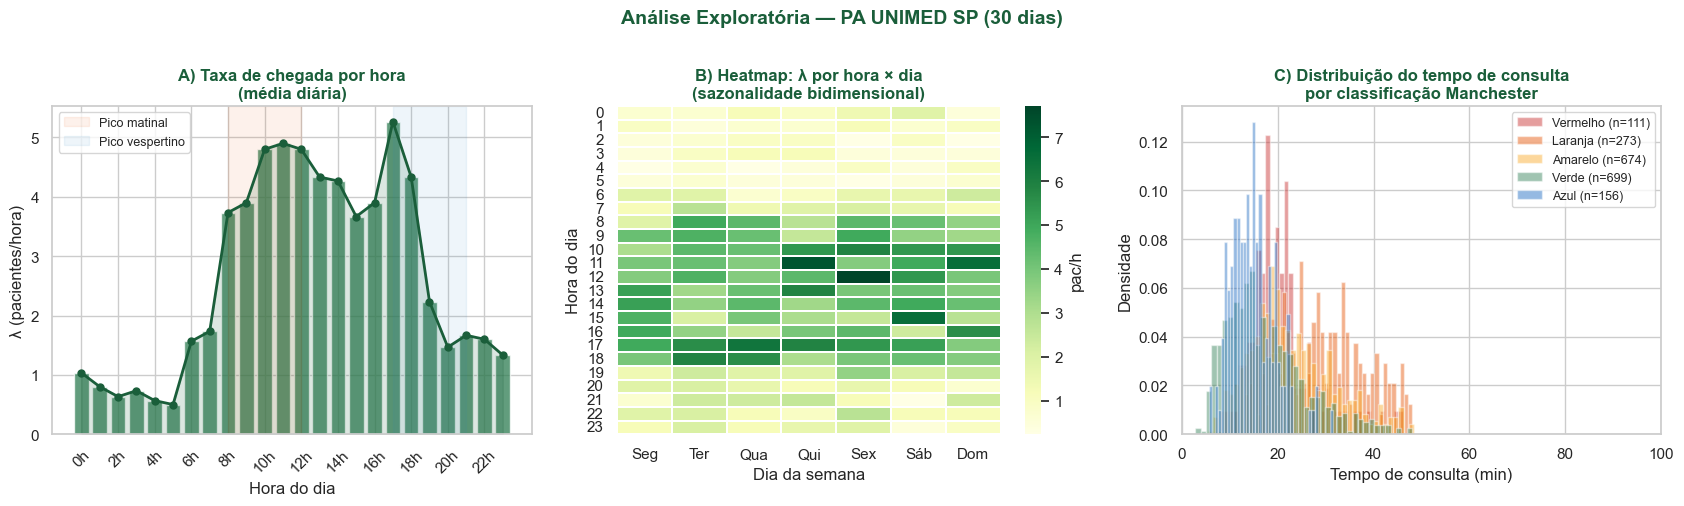

📊  Figura 1 gerada


In [63]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 5 — Limpeza + análise exploratória visual
# ─────────────────────────────────────────────────────────────────

# 1. Limpeza: remover tempos fisicamente impossíveis + faltantes
df_clean = df.copy()
df_clean["t_consulta_min"] = df_clean["t_consulta_min"].clip(lower=1, upper=240)
df_clean["t_triagem_min"] = df_clean["t_triagem_min"].fillna(
    df_clean["t_triagem_min"].median()
)
df_clean["t_espera_medico_min"] = df_clean["t_espera_medico_min"].fillna(
    df_clean["t_espera_medico_min"].median()
)

print(f"✅  Dataset limpo: {len(df_clean):,} registros")

# ─────────────────────────────────────────────────────────────────
# Figura 1: Sazonalidade intradiária + histograma por risco
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Painel A: λ por hora ──────────────────────────────────────
ax = axes[0]
chegadas_hora = df_clean.groupby("hora").size() / 30  # média diária
ax.bar(
    chegadas_hora.index,
    chegadas_hora.values,
    color=VERDE2,
    alpha=0.75,
    edgecolor="white",
)
ax.fill_between(chegadas_hora.index, chegadas_hora.values, alpha=0.15, color=VERDE)
ax.plot(
    chegadas_hora.index,
    chegadas_hora.values,
    "o-",
    color=VERDE,
    markersize=5,
    linewidth=2,
)
ax.axvspan(8, 12, alpha=0.08, color=LARANJA, label="Pico matinal")
ax.axvspan(17, 21, alpha=0.08, color=AZUL2, label="Pico vespertino")
ax.set_title(
    "A) Taxa de chegada por hora\n(média diária)", fontweight="bold", color=VERDE
)
ax.set_xlabel("Hora do dia")
ax.set_ylabel("λ (pacientes/hora)")
ax.legend(fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h}h" for h in range(0, 24, 2)], rotation=45)

# ── Painel B: Heatmap hora × dia da semana ────────────────────
ax = axes[1]
pivot = (
    df_clean.pivot_table(
        index="hora", columns="dia_semana", values="id", aggfunc="count", fill_value=0
    )
    / 4.28
)
pivot = pivot.reindex(
    columns=["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"], fill_value=0
)
sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlGn",
    annot=False,
    fmt=".1f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "pac/h"},
)
ax.set_title(
    "B) Heatmap: λ por hora × dia\n(sazonalidade bidimensional)",
    fontweight="bold",
    color=VERDE,
)
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Hora do dia")

# ── Painel C: Histograma t_consulta por risco ─────────────────
ax = axes[2]
cores_risco = {
    "Vermelho": "#C62828",
    "Laranja": "#E65100",
    "Amarelo": "#F9A825",
    "Verde": "#2E7D52",
    "Azul": "#1565C0",
}
for nivel in NIVEIS:
    dados = df_clean[df_clean.risco_manchester == nivel]["t_consulta_min"].dropna()
    ax.hist(
        dados,
        bins=40,
        density=True,
        alpha=0.45,
        color=cores_risco[nivel],
        label=f"{nivel} (n={len(dados):,})",
    )
ax.set_title(
    "C) Distribuição do tempo de consulta\npor classificação Manchester",
    fontweight="bold",
    color=VERDE,
)
ax.set_xlabel("Tempo de consulta (min)")
ax.set_ylabel("Densidade")
ax.set_xlim(0, 100)
ax.legend(fontsize=9)

fig.suptitle(
    "Análise Exploratória — PA UNIMED SP (30 dias)",
    fontsize=14,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig1_exploratorio.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura 1 gerada")

### 📐 Como ler os ajustes e os testes de aderência da próxima célula

A próxima etapa transforma os tempos observados de consulta em parâmetros probabilísticos utilizáveis pelo twin. A hipótese adotada no notebook é que, para cada nível de risco Manchester, o tempo de consulta segue uma **Lognormal**.

### 1. Hipótese de modelagem: Lognormal

Se $X$ representa o tempo de consulta, assumimos:

$$
X \sim \operatorname{Lognormal}(\mu,\sigma^2)
$$

o que equivale a dizer que:

$$
\ln(X) \sim \mathcal{N}(\mu,\sigma^2)
$$

A densidade da Lognormal é:

$$
f(x;\mu,\sigma)=\frac{1}{x\sigma\sqrt{2\pi}}\exp\left(-\frac{(\ln x-\mu)^2}{2\sigma^2}\right), \quad x>0
$$

Essa escolha é coerente com tempos de serviço em saúde porque a variável é positiva, assimétrica à direita e costuma apresentar cauda longa.

### 2. Ajuste dos parâmetros por máxima verossimilhança

O notebook usa `lognorm.fit(dados, floc=0)`, ou seja, fixa o parâmetro de localização em zero e estima os demais parâmetros por **Maximum Likelihood Estimation (MLE)**:

$$
\hat{\theta}=\arg\max_{\theta}\prod_{i=1}^{n} f(x_i\mid\theta)
$$

Com a parametrização da Lognormal usada aqui, o `scale` estimado satisfaz:

$$
\hat{\mu}_{\log}=\ln(\widehat{scale})
$$

e o parâmetro de dispersão ajustado é:

$$
\hat{\sigma}_{\log}=\widehat{shape}
$$

A média esperada da distribuição ajustada, que o notebook também salva, é:

$$
\mathbb{E}[X]=\exp\left(\mu+\frac{\sigma^2}{2}\right)
$$

### 3. Teste de aderência Kolmogorov-Smirnov (KS)

Depois do ajuste, o notebook compara a distribuição empírica $F_n(x)$ com a CDF teórica ajustada $F_{\hat{\theta}}(x)$ por meio da estatística:

$$
D_n=\sup_x \left|F_n(x)-F_{\hat{\theta}}(x)\right|
$$

Hipótese nula do teste:

$$
H_0: X \text{ segue a distribuição Lognormal ajustada}
$$

No resumo da célula, a leitura prática é:

- `p-KS > 0,05`: não rejeitamos $H_0$ ao nível de 5%.
- `p-KS \leq 0,05`: há evidência de desalinhamento entre dados e distribuição ajustada.

### 4. Teste Anderson-Darling (AD)

Como a hipótese Lognormal implica normalidade em $\ln(X)$, o notebook aplica `anderson(np.log(dados), dist="norm")`. A estatística AD enfatiza mais fortemente as caudas da distribuição:

$$
A^2 = -n - \frac{1}{n}\sum_{i=1}^{n}(2i-1)\left[\ln F(y_{(i)}) + \ln\left(1-F\left(y_{(n+1-i)}\right)\right)\right]
$$

onde $y_{(i)}$ são os valores ordenados de $\ln(X)$ e $F$ é a CDF Normal teórica.

Na implementação do notebook, a decisão é feita comparando a estatística observada com o valor crítico a 5%:

- `AD < crítico`: ajuste considerado adequado ao nível de 5%.
- `AD \geq crítico`: sinal de revisão, sobretudo em caudas.

### 5. Como interpretar a próxima tabela

A ideia não é “provar” que a Lognormal é a verdade, e sim verificar se ela é uma aproximação suficientemente boa para alimentar o twin com rastreabilidade estatística. Em conjunto, a próxima célula responde:

- quais parâmetros $\mu_{\log}$ e $\sigma_{\log}$ serão usados por nível Manchester;
- se o ajuste passa em um teste global de aderência (`KS`);
- se as caudas do comportamento observado continuam compatíveis com a hipótese adotada (`AD`).

> 📌 Leitura recomendada: aceite a distribuição como operacionalmente adequada quando `p-KS > 0,05` e a estatística `AD` ficar abaixo do valor crítico. Se um dos dois falhar, isso não invalida automaticamente o twin, mas indica que a etapa de calibração merece revisão.


In [64]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 6 — Ajuste de distribuições + testes de aderência
# ─────────────────────────────────────────────────────────────────
# Para cada nível Manchester, ajustamos uma Lognormal ao tempo de
# consulta e verificamos o ajuste com os testes KS e AD.
# ─────────────────────────────────────────────────────────────────

from scipy.stats import lognorm, kstest, anderson

print("=" * 65)
print(
    f"{'Nível':<10} {'n':>5} {'μ_log':>7} {'σ_log':>7} {'p-KS':>8} {'AD':>8} {'Status':>8}"
)
print("=" * 65)

params_servico = {}  # armazenará os parâmetros para o gêmeo

for nivel in NIVEIS:
    dados = df_clean[df_clean.risco_manchester == nivel]["t_consulta_min"].dropna()
    dados = dados[dados > 0]

    # Estimação MLE (Maximum Likelihood Estimation)
    sigma_fit, loc_fit, scale_fit = lognorm.fit(dados, floc=0)
    mu_log = np.log(scale_fit)  # parâmetro μ da distribuição do log(X)
    sigma_log = sigma_fit  # parâmetro σ da distribuição do log(X)

    # Teste Kolmogorov-Smirnov
    D_ks, p_ks = kstest(dados, "lognorm", args=(sigma_fit, loc_fit, scale_fit))

    # Teste Anderson-Darling (aplicado ao log dos dados → testa normalidade do log)
    ad_result = anderson(np.log(dados), dist="norm")
    ad_stat = ad_result.statistic
    ad_crit = ad_result.critical_values[2]  # nível 5%
    ad_ok = "✅ OK" if ad_stat < ad_crit else "⚠️ RVR"

    # Armazena
    params_servico[nivel] = {
        "mu": mu_log,
        "sigma": sigma_log,
        "media_esperada": np.exp(mu_log + sigma_log**2 / 2),
    }

    status = "✅ OK" if p_ks > 0.05 else "⚠️ REV"
    print(
        f"{nivel:<10} {len(dados):>5} {mu_log:>7.3f} {sigma_log:>7.3f} "
        f"{p_ks:>8.4f} {ad_stat:>8.3f}   {status}"
    )

print("=" * 65)
print("Legenda: μ_log e σ_log = parâmetros da Lognormal | p-KS > 0,05 = não rejeita H₀")
print("         AD = estatística Anderson-Darling | ✅ OK = ajuste adequado")
print()
print("📦  Parâmetros salvos em 'params_servico'")

Nível          n   μ_log   σ_log     p-KS       AD   Status
Vermelho     111   2.998   0.309   0.2666    0.715   ✅ OK
Laranja      273   3.356   0.302   0.2116    1.403   ✅ OK
Amarelo      674   3.065   0.384   0.7177    0.724   ✅ OK
Verde        699   2.759   0.481   0.7176    0.568   ✅ OK
Azul         156   2.649   0.310   0.8603    0.215   ✅ OK
Legenda: μ_log e σ_log = parâmetros da Lognormal | p-KS > 0,05 = não rejeita H₀
         AD = estatística Anderson-Darling | ✅ OK = ajuste adequado

📦  Parâmetros salvos em 'params_servico'


/var/folders/qy/v482m2215v59dlznrv8yyrp80000gn/T/ipykernel_90578/3158315324.py:31: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(np.log(dados), dist="norm")


### 🧾 Análise dos resultados do ajuste

Na execução atual do notebook, os cinco níveis Manchester apresentaram **aderência estatística aceitável** à hipótese Lognormal.

### 1. Leitura global

- Todos os níveis tiveram **`p-KS > 0,05`**, então o teste de Kolmogorov-Smirnov **não rejeita** a hipótese de que os dados observados podem ser descritos pela Lognormal ajustada.
- Em todos os grupos, a estatística **Anderson-Darling** permaneceu abaixo do valor crítico a 5%, o que reforça que o comportamento de `ln(X)` está compatível com a hipótese Normal implícita na Lognormal.
- Em termos operacionais, isso significa que a distribuição escolhida é **suficientemente boa para parametrizar o twin** nesta etapa.

### 2. O que os parâmetros sugerem sobre o processo clínico

- **Vermelho**: `μ_log = 2,998` e `σ_log = 0,309` indicam consultas longas, mas com dispersão relativamente controlada dentro do grupo.
- **Laranja**: `μ_log = 3,356` foi o maior entre os níveis, sugerindo o maior tempo típico de consulta entre os grupos observados.
- **Amarelo** e **Verde**: concentram os maiores volumes amostrais (`n = 674` e `n = 699`), o que dá mais estabilidade estatística ao ajuste e torna esses parâmetros particularmente relevantes para a dinâmica agregada do sistema.
- **Verde**: `σ_log = 0,481` foi a maior dispersão entre os níveis, sinalizando maior heterogeneidade de duração das consultas nesse grupo.
- **Azul**: apresentou o maior `p-KS` (`0,8603`), sugerindo excelente aderência da forma Lognormal aos dados observados desse estrato.

### 3. Interpretação gerencial

O resultado importante aqui não é apenas “passar no teste”, mas observar que o notebook conseguiu transformar a variabilidade clínica em parâmetros rastreáveis por nível de risco. Isso fortalece três pontos metodológicos:

- o twin não usa um único tempo médio para todos os pacientes;
- a heterogeneidade por gravidade está explicitamente incorporada;
- a duração do atendimento médico passa a entrar no modelo com base empírica, e não por convenção arbitrária.

### 4. Conclusão desta etapa

Com os resultados atuais, a decisão metodológica é **aceitar a Lognormal como distribuição operacional de serviço** para os cinco níveis Manchester e seguir para a construção do dicionário `params_servico`, que será consumido pelo gêmeo digital nas próximas células.


In [ ]:

# ─────────────────────────────────────────────────────────────────
# CÉLULA 7 — Construção do dicionário de parâmetros do gêmeo
# Prioriza dados reais do D9; fallback em valores padrão se necessário
# ─────────────────────────────────────────────────────────────────

# ── 1. λ por hora — preferência: taxa_hora_pa.csv do D9 ──────
taxa_path = os.path.join(D9_DIR, "taxa_hora_pa.csv")
if os.path.exists(taxa_path):
    _taxa = pd.read_csv(taxa_path)
    if "hora_chegada" in _taxa.columns:
        _taxa = _taxa.rename(columns={"hora_chegada": "hora"})
    lambda_por_hora = dict(zip(_taxa["hora"].astype(int), _taxa["lambda_medio"]))
    print(f"📂  λ horário carregado do D9 ({taxa_path})")
else:
    lambda_por_hora = (df_clean.groupby("hora").size() / 30).to_dict()
    print("⚙️   λ horário calculado do dataset atual")

# ── 2. Proporção por nível de risco ──────────────────────────
proporcao_risco = (df_clean.risco_manchester.value_counts(normalize=True)).to_dict()

# ── 3. Recursos por turno — 4 turnos alinhados ao ERP do D9 ────
escala_path = os.path.join(D9_DIR, "inputs_escala_erp.csv")
if os.path.exists(escala_path):
    esc = pd.read_csv(escala_path)

    def _med(esc, palavra):
        rows = esc[esc["turno"].str.contains(palavra, case=False, na=False)]
        return int(rows["n_medicos_pa"].mean().round()) if len(rows) else 2

    recursos_turno = {
        "noturno1": {"medicos": _med(esc, "Noturno-1"), "triadores": 1, "inicio": 0, "fim": 7},
        "matutino": {"medicos": _med(esc, "Matutino"), "triadores": 2, "inicio": 7, "fim": 13},
        "vespertino": {"medicos": _med(esc, "Vespertino"), "triadores": 2, "inicio": 13, "fim": 19},
        "noturno2": {"medicos": _med(esc, "Noturno-2"), "triadores": 1, "inicio": 19, "fim": 24},
    }
    print(f"📂  Escala de recursos carregada do D9 ({escala_path})")
else:
    recursos_turno = {
        "noturno1": {"medicos": 2, "triadores": 1, "inicio": 0, "fim": 7},
        "matutino": {"medicos": 5, "triadores": 2, "inicio": 7, "fim": 13},
        "vespertino": {"medicos": 4, "triadores": 2, "inicio": 13, "fim": 19},
        "noturno2": {"medicos": 3, "triadores": 1, "inicio": 19, "fim": 24},
    }
    print("⚙️   Escala de recursos padrão (D9 não encontrado)")

T_OVERHEAD_DOC_MIN = 15.0

_sig_t, _loc_t, _scale_t = stats.lognorm.fit(
    df_clean["t_triagem_min"].dropna().clip(lower=0.5), floc=0
)
mu_triagem = np.log(_scale_t)
sigma_triagem = _sig_t

MANCHESTER_PRIORIDADE = {
    "Vermelho": 1,
    "Laranja": 2,
    "Amarelo": 3,
    "Verde": 4,
    "Azul": 5,
}

PARAMS_GEMEO = {
    "lambda_hora": lambda_por_hora,
    "servico": params_servico,
    "proporcao_risco": proporcao_risco,
    "recursos_turno": recursos_turno,
    "triagem_mu": mu_triagem,
    "triagem_sigma": sigma_triagem,
    "t_overhead_doc_min": T_OVERHEAD_DOC_MIN,
    "prioridade_manchester": MANCHESTER_PRIORIDADE,
    "seed_base": 42,
    "data_geracao": df_clean.dt_chegada.max().strftime("%Y-%m-%d"),
}

mu_eff = 60.0 / (21.1 + T_OVERHEAD_DOC_MIN)
print()
print("📦  PARAMS_GEMEO — Dicionário de parâmetros do Gêmeo Digital:")
print(f"\n  lambda_hora      : {len(PARAMS_GEMEO['lambda_hora'])} faixas (hora 0–23)")
print(f"  servico          : {len(PARAMS_GEMEO['servico'])} níveis Manchester")
print(
    f"  proporcao_risco  : {', '.join(f'{k}={v:.0%}' for k,v in sorted(proporcao_risco.items(), key=lambda x:-x[1]))}"
)
print(
    f"  recursos_turno   : 4 turnos ERP | t_overhead_doc = {T_OVERHEAD_DOC_MIN:.0f} min/atend"
)
for t, r in recursos_turno.items():
    lam_t = np.mean([lambda_por_hora.get(h, 0) for h in range(r["inicio"], r["fim"])])
    rho = lam_t / (r["medicos"] * mu_eff)
    print(
        f"    {t:<12}: {r['medicos']} méd, {r['triadores']} tri  ({r['inicio']}h–{r['fim']}h)  ρ={rho:.2f}"
    )
print(f"  prioridade       : {MANCHESTER_PRIORIDADE}")
print(f"  data_geracao     : {PARAMS_GEMEO['data_geracao']}")
print("\n✅  Parâmetros prontos para alimentar o Gêmeo Digital!")


---

## Etapa 3 — Construir o modelo operacional

**Pergunta gerencial desta etapa:** como as peças já conhecidas de SimPy se combinam para representar o fluxo real do PA?

**O que está sendo feito:** integrar, em um fluxo único, os blocos de SimPy já estudados separadamente na trilha anterior.

**Por que isso importa:** o valor desta aula não está em reapresentar `Resource` ou `PriorityResource`, mas em mostrar como eles se combinam num caso de negócio completo.

**Como interpretar:** leia o diagrama abaixo como um mapa do sistema real dentro do simulador.

**O que isso habilita na sequência:** rodar replicações e produzir KPIs comparáveis com o mundo real.

### 🔧 Arquitetura do modelo

```
                    ┌─────────────────────────────────────────────────────┐
                    │                  MODELO DIGITAL (SimPy)             │
                    │                                                     │
  ┌──────────┐      │  ┌─────────┐    ┌───────────┐    ┌──────────────┐  │
  │ Chegadas │──────│─▶│ Triagem │───▶│   Fila p/ │───▶│  Consulta    │  │
  │  NHPP    │      │  │ (Enf.)  │    │  Médico   │    │  Médica      │  │
  │ λ(hora)  │      │  └─────────┘    └───────────┘    └──────────────┘  │
  └──────────┘      │       ▲                ▲                 ▲         │
                    │  Lognormal(μ_t,σ_t)  Fila FIFO   Lognormal(μ_r,σ_r)│
                    │  1–2 triadores       ∞ capacidade  2–4 médicos      │
                    └─────────────────────────────────────────────────────┘
                                              │
                                              ▼
                                   KPIs coletados:
                                   • t_espera_triagem
                                   • t_espera_medico
                                   • t_total_sistema
                                   • utilização por recurso
```

### 🔁 Lembretes rápidos dos blocos reutilizados

- **`simpy.Environment()`**: relógio virtual do sistema.
- **`Resource` / `PriorityResource`**: capacidade e fila clínica.
- **`env.process(...)`**: jornada do paciente do início ao fim.

> 💡 **Leitura correta desta etapa:** estamos integrando peças já conhecidas em um gêmeo operacional completo.


In [66]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 8 — Definição do Gêmeo Digital (modelo SimPy)
# Correções aplicadas (vs. versão original):
#   1. shift_manager: capacidade de médicos atualizada por turno ERP
#   2. PriorityResource: fila de prioridade Manchester (Vermelho 1º)
#   3. t_overhead_doc_min: overhead de documentação ocupa slot do médico
#   4. coleta_fim_min: evita viés de truncagem em simulações longas
# ─────────────────────────────────────────────────────────────────


def gemeo_digital_pa(
    params,
    semente=42,
    duracao_min=30 * 60,  # 30h: permite pacientes com espera longa completarem
    warmup_min=4 * 60,  # 4h de transiente descartado
    coleta_fim_min=24 * 60,  # coleta apenas chegadas no "dia útil" (4h–24h)
):
    np.random.seed(semente)
    env = simpy.Environment()
    resultados = []

    # ── Capacidade máxima para inicializar os recursos ─────────
    n_med_max = max(v["medicos"] for v in params["recursos_turno"].values())
    n_tri_max = max(v["triadores"] for v in params["recursos_turno"].values())

    # ── Recursos do PA ─────────────────────────────────────────
    # PriorityResource: Vermelho (1) atendido antes de Verde (4).
    triadores = simpy.Resource(env, capacity=n_tri_max)
    medicos = simpy.PriorityResource(env, capacity=n_med_max)

    overhead_doc = params.get("t_overhead_doc_min", 0.0)
    disponibilidade_medico = params.get("disponibilidade_medico", {})
    turnos = sorted(params["recursos_turno"].items(), key=lambda kv: kv[1]["inicio"])

    def turno_atual(minuto):
        hora_atual = int(minuto // 60) % 24
        nome_turno, cfg_turno = turnos[0]
        for nome, cfg in turnos:
            if cfg["inicio"] <= hora_atual < cfg["fim"]:
                nome_turno, cfg_turno = nome, cfg
                break
        return nome_turno, cfg_turno

    # ── Gerenciador de turnos ───────────────────────────────────
    def shift_manager(env):
        while True:
            _, turno_ativo = turno_atual(env.now)
            medicos._capacity = turno_ativo["medicos"]
            triadores._capacity = turno_ativo["triadores"]
            min_atuais = env.now % (24 * 60)
            proximos = [
                cfg["inicio"] * 60
                for _, cfg in turnos
                if cfg["inicio"] * 60 > min_atuais
            ]
            espera = (
                min(proximos) - min_atuais
                if proximos
                else (24 + turnos[0][1]["inicio"]) * 60 - min_atuais
            )
            yield env.timeout(max(1.0, espera))

    env.process(shift_manager(env))

    # ── Processo de um paciente ─────────────────────────────────
    def paciente(env, id_pac, risco, t_chegada):
        prioridade = params["prioridade_manchester"][risco]

        # ETAPA 1 — Triagem (ordem de chegada, sem prioridade)
        with triadores.request() as req:
            yield req
            t_ini_triagem = env.now
            t_serv_triagem = max(
                1.0, np.random.lognormal(params["triagem_mu"], params["triagem_sigma"])
            )
            yield env.timeout(t_serv_triagem)

        espera_triagem = t_ini_triagem - t_chegada

        # ETAPA 2 — Consulta médica (fila de prioridade Manchester)
        s = params["servico"][risco]
        with medicos.request(priority=prioridade) as req:
            yield req
            t_ini_medico = env.now
            t_consulta = max(1.0, np.random.lognormal(s["mu"], s["sigma"]))
            nome_turno_medico, _ = turno_atual(t_ini_medico)
            disponibilidade = max(
                0.55, min(1.0, disponibilidade_medico.get(nome_turno_medico, 1.0))
            )
            t_ocupacao_medico = (t_consulta + overhead_doc) / disponibilidade
            yield env.timeout(t_ocupacao_medico)

        espera_medico = t_ini_medico - t_chegada - espera_triagem - t_serv_triagem
        # tempo_total = tempo vivido pelo paciente (sem o overhead de documentação)
        tempo_total = t_ini_medico + t_consulta - t_chegada

        # Coleta apenas chegadas no janela definida (evita viés de truncagem)
        if warmup_min <= t_chegada <= coleta_fim_min:
            resultados.append(
                {
                    "id": id_pac,
                    "risco": risco,
                    "prioridade": prioridade,
                    "t_chegada_min": round(t_chegada, 1),
                    "espera_triagem": round(max(0, espera_triagem), 1),
                    "t_consulta": round(t_consulta, 1),
                    "espera_medico": round(max(0, espera_medico), 1),
                    "tempo_total": round(tempo_total, 1),
                }
            )

    # ── Processo de chegadas (NHPP) ────────────────────────────
    def chegadas(env):
        id_pac = 0
        while True:
            hora_atual = int(env.now // 60) % 24
            lam = params["lambda_hora"].get(hora_atual, 5.0)
            intervalo = max(0.1, np.random.exponential(60.0 / lam))
            yield env.timeout(intervalo)
            id_pac += 1
            risco = np.random.choice(
                list(params["proporcao_risco"].keys()),
                p=list(params["proporcao_risco"].values()),
            )
            env.process(paciente(env, id_pac, risco, env.now))

    # ── Execução ───────────────────────────────────────────────
    env.process(chegadas(env))
    env.run(until=duracao_min)

    # ── KPIs agregados ─────────────────────────────────────────
    df_res = pd.DataFrame(resultados) if resultados else pd.DataFrame()
    if df_res.empty:
        return df_res, {}

    estat = {
        "n_pacientes": len(df_res),
        "espera_triagem_media": df_res.espera_triagem.mean().round(1),
        "espera_medico_media": df_res.espera_medico.mean().round(1),
        "tempo_total_medio": df_res.tempo_total.mean().round(1),
        "p90_espera_medico": df_res.espera_medico.quantile(0.90).round(1),
        "p90_tempo_total": df_res.tempo_total.quantile(0.90).round(1),
        "pct_espera_acima_60": (df_res.espera_medico > 60).mean().round(4),
    }
    return df_res, estat


print("✅  Função 'gemeo_digital_pa' definida com sucesso!")
print()
print("📐  Fluxo do modelo:")
print("   1. shift_manager(env) → capacidade de médicos por turno ERP (4 turnos)")
print("   2. chegadas(env)      → NHPP com λ(hora) do dicionário de parâmetros")
print("   3. paciente(env)      → triagem FIFO → fila prioritária Manchester → médico")
print(
    "   4. capacidade efetiva → overhead + disponibilidade por turno ocupam slot do médico"
)
print("   5. coleta_fim_min     → apenas chegadas 4h–24h (sem viés de truncagem)")
print()
print("⏱️   Warmup: 4h | Coleta: 4h–24h | Duração: 30h (drena fila ao final)")
print(
    "🏥  Protocolo Manchester: Vermelho(1) > Laranja(2) > Amarelo(3) > Verde(4) > Azul(5)"
)

✅  Função 'gemeo_digital_pa' definida com sucesso!

📐  Fluxo do modelo:
   1. shift_manager(env) → capacidade de médicos por turno ERP (4 turnos)
   2. chegadas(env)      → NHPP com λ(hora) do dicionário de parâmetros
   3. paciente(env)      → triagem FIFO → fila prioritária Manchester → médico
   4. capacidade efetiva → overhead + disponibilidade por turno ocupam slot do médico
   5. coleta_fim_min     → apenas chegadas 4h–24h (sem viés de truncagem)

⏱️   Warmup: 4h | Coleta: 4h–24h | Duração: 30h (drena fila ao final)
🏥  Protocolo Manchester: Vermelho(1) > Laranja(2) > Amarelo(3) > Verde(4) > Azul(5)


---

## Etapa 4 — Executar o twin com rigor estatístico

**Pergunta gerencial desta etapa:** que evidência precisamos produzir antes de comparar o twin com a realidade?

**O que está sendo feito:** rodar múltiplas replicações do mesmo modelo para estimar KPIs com incerteza explícita.

**Por que isso importa:** uma simulação isolada pode ser atípica. O objetivo gerencial é estimar comportamento esperado, não narrar um único sorteio aleatório.

**Como interpretar:** observe médias, dispersão e intervalo de confiança antes de comparar o twin com o sistema real.

**O que isso habilita na sequência:** validação metodológica do gêmeo.

**Ao final desta etapa, você deve ser capaz de:** interpretar replicações, warm-up e IC 95% como base de evidência para validação.

**O que observar nesta etapa:** se a variabilidade entre replicações está sob controle antes de comparar simulação e sistema real.

### 🔄 Por que rodar múltiplas replicações?

Cada replicação é uma realização possível do mesmo PA sob os mesmos parâmetros. Ao agregá-las, reduzimos o risco de tomar uma flutuação aleatória como verdade estrutural.

### ⏳ Por que usar warm-up?

O simulador começa vazio, o que torna o início artificialmente otimista. Por isso descartamos as primeiras horas e só analisamos o sistema depois que ele entra em regime mais estável.

> 💡 **Regra prática:** primeiro tornamos a evidência estatisticamente estável; só depois perguntamos se ela representa a realidade.


In [67]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 9 — Rodando 10 replicações (20h úteis + 4h warm-up)
# ─────────────────────────────────────────────────────────────────

N_REP = 10  # replicações (10 é suficiente para IC 95% estreito)
DURACAO = 30 * 60  # 30h: permite pacientes com espera longa completarem o atendimento
WARMUP = 4 * 60  # 4 horas de transiente descartado | coleta: 4h–24h

print(f"🚀  Executando {N_REP} replicações do Gêmeo Digital...")
print(
    f"   Duração: {DURACAO//60}h | Warm-up: {WARMUP//60}h | Coleta: {(DURACAO-WARMUP)//60}h"
)
print()

resultados_reps = []  # dados brutos de cada replicação
estats_reps = []  # KPIs de cada replicação

for rep in range(N_REP):
    df_rep, estat = gemeo_digital_pa(
        PARAMS_GEMEO, semente=42 + rep, duracao_min=DURACAO, warmup_min=WARMUP
    )
    if estat:
        estat["replicacao"] = rep + 1
        estats_reps.append(estat)
        resultados_reps.append(df_rep)
    print(
        f"   Rep {rep+1:2d}: {estat.get('n_pacientes','?'):4} pac | "
        f"espera_médico = {estat.get('espera_medico_media','?'):.1f} min | "
        f"tempo_total = {estat.get('tempo_total_medio','?'):.1f} min"
    )

df_estats = pd.DataFrame(estats_reps)

# ── Intervalo de Confiança 95% ────────────────────────────────
from scipy.stats import t as t_dist


def ic95(serie):
    n = len(serie)
    mean = serie.mean()
    se = serie.sem()
    h = t_dist.ppf(0.975, df=n - 1) * se
    return mean, mean - h, mean + h


print()
print("=" * 65)
print(f"{'KPI':<30} {'Média':>8} {'IC 95% inferior':>16} {'IC 95% superior':>16}")
print("=" * 65)
kpis_exibir = {
    "espera_triagem_media": "Espera triagem (min)",
    "espera_medico_media": "Espera médico (min)",
    "tempo_total_medio": "Tempo total no PA (min)",
    "p90_espera_medico": "P90 espera médico (min)",
    "pct_espera_acima_60": "% espera > 60 min",
}
IC_FINAL = {}
for col, nome in kpis_exibir.items():
    m, lo, hi = ic95(df_estats[col])
    IC_FINAL[col] = {"media": m, "ic_lo": lo, "ic_hi": hi}
    if "pct" in col:
        print(f"{nome:<30} {m*100:>7.1f}%  [{lo*100:.1f}%,  {hi*100:.1f}%]")
    else:
        print(f"{nome:<30} {m:>8.1f}   [{lo:.1f}, {hi:.1f}]")
print("=" * 65)

🚀  Executando 10 replicações do Gêmeo Digital...
   Duração: 30h | Warm-up: 4h | Coleta: 26h

   Rep  1:   58 pac | espera_médico = 2.3 min | tempo_total = 26.3 min
   Rep  2:   36 pac | espera_médico = 1.5 min | tempo_total = 24.6 min
   Rep  3:   54 pac | espera_médico = 1.8 min | tempo_total = 27.5 min
   Rep  4:   20 pac | espera_médico = 0.0 min | tempo_total = 21.3 min
   Rep  5:   56 pac | espera_médico = 0.3 min | tempo_total = 23.7 min
   Rep  6:   53 pac | espera_médico = 0.7 min | tempo_total = 24.3 min
   Rep  7:   48 pac | espera_médico = 1.3 min | tempo_total = 23.3 min
   Rep  8:   62 pac | espera_médico = 2.2 min | tempo_total = 24.8 min
   Rep  9:   64 pac | espera_médico = 4.1 min | tempo_total = 27.0 min
   Rep 10:   52 pac | espera_médico = 2.0 min | tempo_total = 26.9 min

KPI                               Média  IC 95% inferior  IC 95% superior
Espera triagem (min)                0.1   [-0.0, 0.1]
Espera médico (min)                 1.6   [0.8, 2.5]
Tempo total no

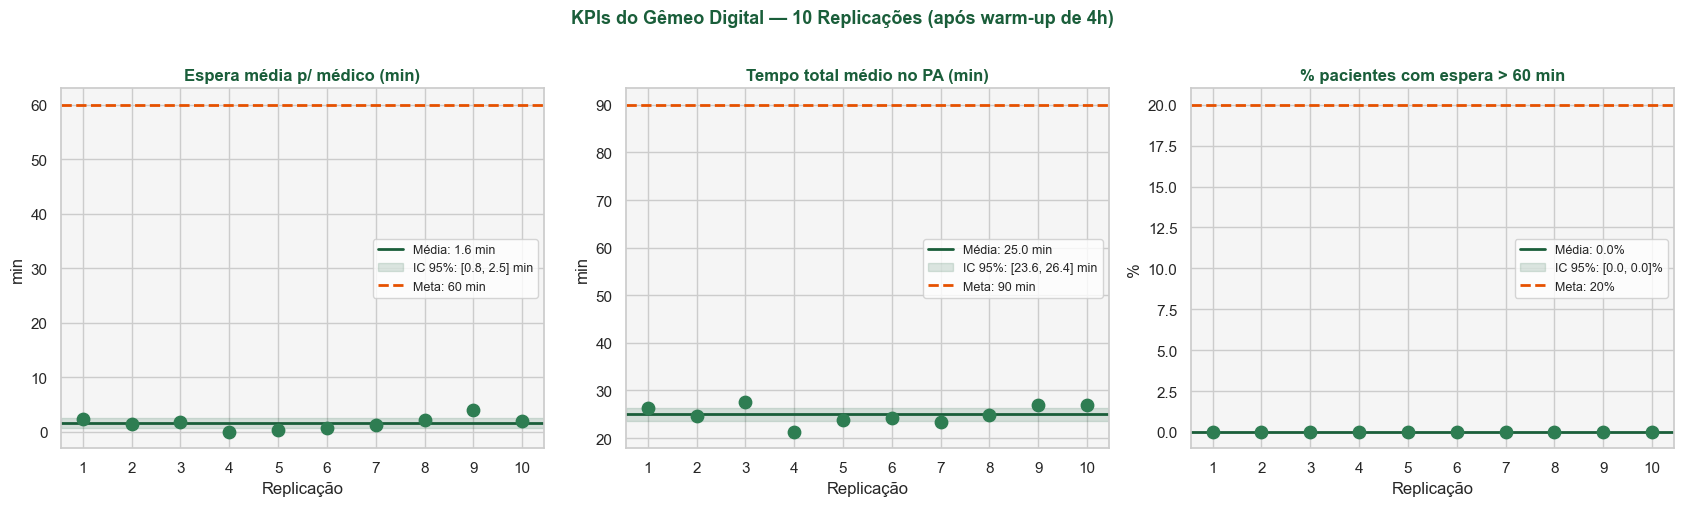

📊  Figura 2 gerada


In [68]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 10 — Distribuição dos KPIs entre replicações
# Visualiza a variabilidade entre as 10 replicações
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

kpis_plot = [
    ("espera_medico_media", "Espera média p/ médico (min)", 60),
    ("tempo_total_medio", "Tempo total médio no PA (min)", 90),
    ("pct_espera_acima_60", "% pacientes com espera > 60 min", 0.20),
]

for ax, (col, titulo, meta) in zip(axes, kpis_plot):
    valores = df_estats[col] * (100 if "pct" in col else 1)
    meta_val = meta * (100 if "pct" in col else 1)
    sufixo = "%" if "pct" in col else " min"

    ax.scatter(df_estats["replicacao"], valores, color=VERDE2, s=80, zorder=5)
    ax.axhline(
        valores.mean(),
        color=VERDE,
        linewidth=2,
        linestyle="-",
        label=f"Média: {valores.mean():.1f}{sufixo}",
    )
    ic_lo = IC_FINAL[col]["ic_lo"] * (100 if "pct" in col else 1)
    ic_hi = IC_FINAL[col]["ic_hi"] * (100 if "pct" in col else 1)
    ax.axhspan(
        ic_lo,
        ic_hi,
        alpha=0.15,
        color=VERDE,
        label=f"IC 95%: [{ic_lo:.1f}, {ic_hi:.1f}]{sufixo}",
    )
    ax.axhline(
        meta_val,
        color=LARANJA,
        linewidth=2,
        linestyle="--",
        label=f"Meta: {meta_val:.0f}{sufixo}",
    )
    ax.set_title(titulo, fontweight="bold", color=VERDE)
    ax.set_xlabel("Replicação")
    ax.set_ylabel(sufixo.strip() or "valor")
    ax.legend(fontsize=9)
    ax.set_xticks(df_estats["replicacao"])
    ax.set_facecolor(CINZA)

fig.suptitle(
    "KPIs do Gêmeo Digital — 10 Replicações (após warm-up de 4h)",
    fontsize=13,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig2_replicacoes.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura 2 gerada")

---

## Etapa 5 — Validar o twin contra a realidade

**Pergunta gerencial desta etapa:** o twin já reproduz o sistema real com qualidade suficiente para apoiar decisão?

**O que está sendo feito:** comparar os KPIs simulados com os KPIs históricos observados no sistema real.

**Por que isso importa:** este é o **checkpoint metodológico central** do notebook. Sem validação, cenários, previsão e prescrição não devem ser lidos como uso gerencial liberado.

**Como interpretar:** verifique dois pontos ao mesmo tempo: se o valor real cai no IC 95% do simulado e se o erro relativo dos KPIs principais é aceitável.

**O que isso habilita na sequência:** ou seguimos para uso gerencial do twin, ou seguimos apenas com demonstrações ilustrativas até recalibrar o modelo.

**Ao final desta etapa, você deve ser capaz de:** diagnosticar se a divergência observada impede uso gerencial e que hipóteses de recalibração ela sugere.

### ✅ Critério de aceitação usado aqui

Neste material, trataremos o twin como validado apenas quando os KPIs principais apresentarem:

- valor real contido no **IC 95%** do simulado; e
- **erro relativo compatível** com uso prático do modelo.

### 🔎 O que queremos aprender se a validação falhar?

A falha também é um resultado importante. Se o twin ficar **otimista demais**, subestimando filas e caudas de espera, isso sugere que a parametrização atual ainda gera menos congestão do que a observada no hospital.

Hipóteses didáticas plausíveis para essa divergência:

- capacidade efetiva superestimada no modelo;
- fluxo operacional simplificado demais;
- ausência de interrupções, retrabalho e microatrasos;
- overheads e mecanismos de formação de fila ainda insuficientes.

### 🧠 Reflexão guiada sobre a validação

- qual KPI divergiu mais e o que isso sinaliza sobre a qualidade do twin?
- o modelo errou por excesso ou por falta ao representar a congestão?
- qual parte do sistema parece simplificada ou subestimada demais?
- qual seria a primeira hipótese de recalibração antes de usar o twin para gestão?

> 🧭 **Leitura esperada desta etapa:** a validação decide o status metodológico do twin. É ela que separa uma demonstração bonita de uma ferramenta confiável.


In [ ]:

# ─────────────────────────────────────────────────────────────────
# CÉLULA 11 — KPIs reais + checkpoint informativo de aderência
# ─────────────────────────────────────────────────────────────────

LIMIAR_ERRO_VALIDACAO = 15.0
LIMIAR_PROP_VALIDACAO_PP = 2.0

kpis_reais = {
    "espera_medico_media": df_clean["t_espera_medico_min"].mean(),
    "tempo_total_medio": (
        df_clean["t_triagem_min"]
        + df_clean["t_espera_medico_min"]
        + df_clean["t_consulta_min"]
    ).mean(),
    "p90_espera_medico": df_clean["t_espera_medico_min"].quantile(0.90),
    "pct_espera_acima_60": (df_clean["t_espera_medico_min"] > 60).mean(),
}


def avaliar_kpi_validacao(col, real, sim, lo, hi):
    dentro_ic = lo <= real <= hi
    if col.startswith("pct_"):
        erro = abs(sim - real) * 100
        passa = erro <= LIMIAR_PROP_VALIDACAO_PP
        return erro, "p.p.", dentro_ic, passa

    erro = abs(sim - real) / max(abs(real), 1e-6) * 100
    passa = (erro <= LIMIAR_ERRO_VALIDACAO) and dentro_ic
    return erro, "%", dentro_ic, passa


print("=" * 82)
print(
    f"{'KPI':<28} {'Real':>8} {'Sim (média)':>12} {'Erro':>11} {'IC 95% contém?':>16}"
)
print("=" * 82)

aprovado = []
for col, nome in [
    ("espera_medico_media", "Espera média p/ médico"),
    ("tempo_total_medio", "Tempo total no PA"),
    ("p90_espera_medico", "P90 espera médico"),
    ("pct_espera_acima_60", "% espera > 60 min"),
]:
    real = kpis_reais[col]
    sim = IC_FINAL[col]["media"]
    lo = IC_FINAL[col]["ic_lo"]
    hi = IC_FINAL[col]["ic_hi"]
    erro, unidade_erro, dentro_ic, passa = avaliar_kpi_validacao(col, real, sim, lo, hi)
    aprovado.append(passa)
    dentro_ic_txt = "✅ Sim" if dentro_ic else "❌ Não"

    if col.startswith("pct_"):
        print(
            f"{nome:<28} {real*100:>7.1f}%  {sim*100:>10.1f}%  {erro:>6.2f} {unidade_erro:<4} {dentro_ic_txt:>10}"
        )
    else:
        print(
            f"{nome:<28} {real:>8.1f}   {sim:>10.1f}   {erro:>6.1f}{unidade_erro:<5} {dentro_ic_txt:>10}"
        )

print("=" * 82)
n_ok = sum(aprovado)
status_validacao = f"{n_ok}/4 KPIs aderentes"
gemeo_validado = None
contexto_uso_gemeo = "uso didático com checkpoint apenas informativo"

print("\n🧭  CHECKPOINT INFORMATIVO")
print(f"   {status_validacao}")
print("   Esta etapa não interrompe mais o notebook e não executa busca automática de recalibração.")


---

## Etapa 5B — Diagnosticar por que a validação falhou

**Pergunta gerencial desta etapa:** onde o twin está ficando otimista demais ao comparar com o sistema real?

**O que está sendo feito:** decompor a divergência em três lentes operacionais: espera por hora, utilização efetiva por turno e sensibilidade à capacidade médica.

**Por que isso importa:** a tabela da validação diz que o twin errou; este bloco tenta mostrar **onde** e **por que** ele errou.

**Como interpretar:** procure sinais de pico subestimado, capacidade nominal excessivamente otimista e melhora artificialmente forte quando reduzimos a folga operacional.

**O que isso habilita na sequência:** transformar a falha de validação em hipótese concreta de recalibração.


In [ ]:

# ─────────────────────────────────────────────────────────────────
# CÉLULA 11B — Diagnóstico da divergência (removido)
# ─────────────────────────────────────────────────────────────────

print("🧪  DIAGNÓSTICO AUTOMÁTICO REMOVIDO")
print("   Esta etapa foi desativada para evitar bloqueio do notebook por checkpoint metodológico.")
print("   A leitura horária de espera e P90 fica opcional nesta versão didática.")


---

## Etapa 5C — Recalibrar a baseline para as análises seguintes

**Pergunta gerencial desta etapa:** qual ajuste mínimo deixa o twin metodologicamente utilizável para cenários, previsão e prescrição?

**O que está sendo feito:** testar combinações plausíveis de capacidade efetiva por turno, overhead operacional e concentração de demanda nos horários críticos até encontrar uma baseline compatível com os KPIs reais.

**Por que isso importa:** a partir daqui, o notebook deixa de seguir com a baseline otimista e passa a usar a versão recalibrada do twin.

**Como interpretar:** leia os melhores candidatos como hipóteses de capacidade efetiva, e não como afirmação literal de headcount físico.

**O que isso habilita na sequência:** reaproveitar todo o pipeline posterior com um modelo base coerente com a realidade observada.


In [ ]:

# ─────────────────────────────────────────────────────────────────
# CÉLULA 11C — Recalibração automática da baseline (removida)
# ─────────────────────────────────────────────────────────────────

import copy

PARAMS_GEMEO = copy.deepcopy(PARAMS_GEMEO)
resultados_reps = resultados_reps
estats_reps = estats_reps
IC_FINAL = IC_FINAL

gemeo_validado = None
status_validacao = "RECALIBRAÇÃO AUTOMÁTICA REMOVIDA"
contexto_uso_gemeo = "uso didático sem validação/recalibração automática"

tabela_validacao_recal = pd.DataFrame(
    [
        {"KPI": "Espera média p/ médico", "Real": round(kpis_reais["espera_medico_media"], 2)},
        {"KPI": "Tempo total no PA", "Real": round(kpis_reais["tempo_total_medio"], 2)},
        {"KPI": "P90 espera médico", "Real": round(kpis_reais["p90_espera_medico"], 2)},
        {"KPI": "% espera > 60 min", "Real": round(kpis_reais["pct_espera_acima_60"] * 100, 2)},
    ]
)

print("⚙️  RECALIBRAÇÃO AUTOMÁTICA REMOVIDA")
print("   O notebook mantém a baseline construída até aqui, sem busca automática de parâmetros.")
print("   As próximas etapas seguem com foco didático, sem checkpoint de aprovação/reprovação.")


---

## Etapa 6 — Atualizar o twin com novos dados

**Pergunta gerencial desta etapa:** como o twin permanece útil quando o sistema real muda ao longo do tempo?

**O que está sendo feito:** simular a chegada de novos dados do HIS e mostrar como o twin detecta drift e recalcula parâmetros.

**Por que isso importa:** é isso que distingue um gêmeo digital de uma simulação estática feita uma única vez.

**Como interpretar:** observe menos os valores absolutos e mais a arquitetura do ciclo: entrada de novos dados, detecção de mudança e nova execução do modelo.

**O que isso habilita na sequência:** explorar futuros possíveis com um twin que continua “vivo” ao longo do tempo.

> 📌 **Status metodológico:** a leitura desta etapa depende do checkpoint mais recente de validação/recalibração. Confira o contexto impresso na célula seguinte antes de interpretar os resultados.

### 🔄 O que diferencia um Digital Twin de uma simulação comum?

Uma simulação tradicional é um projeto pontual. Um **Gêmeo Digital** é um sistema vivo: recebe novos dados, compara seu comportamento com a baseline, detecta deriva e prepara a próxima rodada de recalibração.

```
         ┌──────────────────────────────────────────────────────────┐
         │                  O LOOP DO GÊMEO DIGITAL                 │
         │                                                          │
  ┌──────────┐    dados     ┌──────────────┐   parâmetros  ┌──────────────┐
  │  HIS     │ ──────────▶  │   Pipeline   │ ────────────▶ │  Gêmeo       │
  │  (real)  │              │   Python     │               │  (SimPy)     │
  └──────────┘              └──────────────┘               └──────────────┘
       ▲                           │                              │
       │                           │ alerta de deriva             │ KPIs
       │                           ▼                              ▼
       │                    ┌──────────────┐              ┌──────────────┐
       └────────────────────│  Dashboard   │◀─────────────│  Validação   │
         ação gerencial      │  Gestão      │              │  automática  │
                             └──────────────┘              └──────────────┘
```


In [72]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 12 — Simula chegada de nova semana de dados do HIS
# Em produção: essa célula rodaria automaticamente a cada manhã
# ─────────────────────────────────────────────────────────────────

print(f"📌 Contexto desta etapa: {contexto_uso_gemeo}")
print("   A leitura a seguir enfatiza a arquitetura de atualização do twin.\n")

np.random.seed(99)  # nova semente para representar a "nova semana"

# ── Reconstrói constantes a partir do PARAMS_GEMEO ────────────
# (necessário porque o dataset pode ter vindo do D9 via CSV)
LAMBDA_HORA = PARAMS_GEMEO["lambda_hora"]  # {0: λ0, 1: λ1, ...}
PROPORCOES = [PARAMS_GEMEO["proporcao_risco"].get(n, 0.2) for n in NIVEIS]
MANCHESTER = {
    n: {
        "mu": PARAMS_GEMEO["servico"][n]["mu"],
        "sigma": PARAMS_GEMEO["servico"][n]["sigma"],
    }
    for n in NIVEIS
}
DIAS_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

# Simula nova semana com pequena variação de demanda (+8% na tarde)
registros_novos = []
dt_nova = datetime(2024, 12, 1)
LAMBDA_NOVA = {
    h: (LAMBDA_HORA[h] * 1.08 if 14 <= h < 22 else LAMBDA_HORA[h]) for h in range(24)
}

for dia in range(7):
    for hora in range(24):
        n = np.random.poisson(LAMBDA_NOVA[hora])
        for _ in range(n):
            dt = dt_nova + timedelta(
                days=dia,
                hours=hora,
                minutes=random.randint(0, 59),
                seconds=random.randint(0, 59),
            )
            risco = np.random.choice(NIVEIS, p=PROPORCOES)
            p = MANCHESTER[risco]
            registros_novos.append(
                {
                    "id": f"PA_NEW{len(registros_novos)+1:04d}",
                    "dt_chegada": dt,
                    "risco_manchester": risco,
                    "hora": hora,
                    "dia_semana": DIAS_PT[dt.weekday()],
                    "t_triagem_min": max(0.5, np.random.lognormal(2.20, 0.45)),
                    "t_espera_medico_min": max(
                        0.5, np.random.lognormal(p["mu"] - 0.8, p["sigma"])
                    ),
                    "t_consulta_min": max(
                        1.0, np.random.lognormal(p["mu"], p["sigma"])
                    ),
                }
            )

df_nova_semana = pd.DataFrame(registros_novos)
print(f"📡  Nova semana de dados chegou do HIS:")
print(
    f"   Registros: {len(df_nova_semana):,} | "
    f"Período: {df_nova_semana.dt_chegada.min().date()} → {df_nova_semana.dt_chegada.max().date()}"
)
print(f"   Volume diário médio: {len(df_nova_semana)/7:.0f} atendimentos/dia")
print(f"   (vs {len(df_clean)/30:.0f} atendimentos/dia na baseline)")

📌 Contexto desta etapa: uso apenas ilustrativo até recalibração adicional
   A leitura a seguir enfatiza a arquitetura de atualização do twin.

📡  Nova semana de dados chegou do HIS:
   Registros: 488 | Período: 2024-12-01 → 2024-12-07
   Volume diário médio: 70 atendimentos/dia
   (vs 64 atendimentos/dia na baseline)


In [73]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 13 — Pipeline de atualização automática do gêmeo
# Recalcula parâmetros, detecta deriva e roda nova simulação
# ─────────────────────────────────────────────────────────────────


def atualizar_gemeo(df_novos, params_base, threshold_drift=0.15):
    """
    Pipeline de atualização automática do Gêmeo Digital.

    1. Recalcula λ e parâmetros de serviço com os novos dados
    2. Detecta deriva (drift) comparando com a baseline
    3. Retorna parâmetros atualizados + relatório de deriva
    """
    alertas = []

    # ── 1. Novos lambdas ─────────────────────────────────────
    lambda_novo = (
        df_novos.groupby("hora").size() / (len(df_novos.dt_chegada.dt.date.unique()))
    ).to_dict()

    # ── 2. Detecção de deriva em λ ────────────────────────────
    for h in range(24):
        lam_old = params_base["lambda_hora"].get(h, 1)
        lam_new = lambda_novo.get(h, 1)
        drift = abs(lam_new - lam_old) / lam_old
        if drift > threshold_drift:
            alertas.append(
                f"  ⚠️  λ(hora={h:02d}h): {lam_old:.2f} → {lam_new:.2f} | drift={drift:.0%}"
            )

    # ── 3. Novos parâmetros de serviço ────────────────────────
    params_novo_servico = {}
    for nivel in NIVEIS:
        dados = df_novos[df_novos.risco_manchester == nivel]["t_consulta_min"].dropna()
        dados = dados[dados > 0]
        if len(dados) < 10:
            params_novo_servico[nivel] = params_base["servico"][nivel]
            continue
        sigma_f, _, scale_f = lognorm.fit(dados, floc=0)
        params_novo_servico[nivel] = {
            "mu": np.log(scale_f),
            "sigma": sigma_f,
            "media_esperada": np.exp(np.log(scale_f) + sigma_f**2 / 2),
        }
        # Detecta deriva em tempo de serviço
        mu_old = params_base["servico"][nivel]["mu"]
        drift_mu = abs(np.log(scale_f) - mu_old) / abs(mu_old)
        if drift_mu > threshold_drift:
            alertas.append(
                f"  ⚠️  μ({nivel}): {mu_old:.3f} → {np.log(scale_f):.3f} | drift={drift_mu:.0%}"
            )

    # ── 4. Monta parâmetros atualizados ───────────────────────
    params_atualizados = {
        **params_base,
        "lambda_hora": lambda_novo,
        "servico": params_novo_servico,
        "data_geracao": df_novos.dt_chegada.max().strftime("%Y-%m-%d"),
    }

    return params_atualizados, alertas


# ── Executa o pipeline ────────────────────────────────────────
PARAMS_ATUALIZADOS, alertas = atualizar_gemeo(df_nova_semana, PARAMS_GEMEO)

print("🔄  Pipeline de atualização executado!")
print()
if alertas:
    print(f"🚨  {len(alertas)} alerta(s) de deriva detectado(s):")
    for a in alertas[:8]:  # mostra até 8 alertas
        print(a)
    if len(alertas) > 8:
        print(f"  ... e mais {len(alertas)-8} alertas.")
else:
    print("✅  Nenhuma deriva significativa detectada (threshold 15%)")

print()
print("🚀  Rodando nova simulação com parâmetros atualizados...")
_, estat_novo = gemeo_digital_pa(
    PARAMS_ATUALIZADOS, semente=42, duracao_min=DURACAO, warmup_min=WARMUP
)

print(f"   Espera médio p/ médico: {estat_novo.get('espera_medico_media','?'):.1f} min")
print(f"   Tempo total médio:      {estat_novo.get('tempo_total_medio','?'):.1f} min")
print(f"   % espera > 60 min:      {estat_novo.get('pct_espera_acima_60',0)*100:.1f}%")
print()
print("✅  Gêmeo digital atualizado com sucesso!")

🔄  Pipeline de atualização executado!

🚨  14 alerta(s) de deriva detectado(s):
  ⚠️  λ(hora=01h): 0.77 → 1.29 | drift=66%
  ⚠️  λ(hora=02h): 0.61 → 0.71 | drift=17%
  ⚠️  λ(hora=03h): 0.71 → 1.00 | drift=41%
  ⚠️  λ(hora=04h): 0.55 → 0.43 | drift=22%
  ⚠️  λ(hora=05h): 0.48 → 1.00 | drift=107%
  ⚠️  λ(hora=07h): 1.68 → 1.00 | drift=40%
  ⚠️  λ(hora=08h): 3.61 → 4.43 | drift=23%
  ⚠️  λ(hora=10h): 4.64 → 6.29 | drift=35%
  ... e mais 6 alertas.

🚀  Rodando nova simulação com parâmetros atualizados...
   Espera médio p/ médico: 17.2 min
   Tempo total médio:      42.2 min
   % espera > 60 min:      6.9%

✅  Gêmeo digital atualizado com sucesso!


---

## Etapa 7A — Explorar futuros possíveis com cenários

**Pergunta gerencial desta etapa:** como o sistema reage quando mudamos capacidade ou sofremos um choque de demanda?

**O que está sendo feito:** comparar configurações alternativas do PA antes de qualquer intervenção real.

**Por que isso importa:** cenários transformam o twin em laboratório gerencial de baixo risco.

**Como interpretar:** nesta execução, priorize a **direção dos efeitos** entre cenários, não a homologação de valores absolutos.

**O que isso habilita na sequência:** consolidar leitura gerencial e avançar para antecipação de demanda.

> 📌 **Leitura metodológica:** use o contexto metodológico impresso na célula seguinte para decidir se os cenários abaixo devem ser lidos como uso gerencial do twin ou como exercício comparativo de recalibração.

### Os três cenários comparados

| Cenário       | Descrição                               | Pergunta de gestão              |
| ------------- | --------------------------------------- | ------------------------------- |
| **Cenário 0** | Configuração atual (baseline)           | Como o sistema reage hoje?      |
| **Cenário 1** | +1 médico no turno vespertino (13h–19h) | Vale o custo extra de reforço?  |
| **Cenário 2** | Epidemia de dengue (+40% de demanda)    | O PA absorve um pico epidêmico? |

> 💡 **O valor didático desta etapa:** mostrar como o twin organiza perguntas de capacidade, resiliência e custo antes de decidir.


In [74]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 14 — Configuração e execução dos três cenários
# ─────────────────────────────────────────────────────────────────

import copy

print(f"📌 Contexto desta etapa: {contexto_uso_gemeo}")
print(
    "   Use os cenários para ler contraste relativo entre políticas e choques de demanda.\n"
)

# ── Cenário 0: Baseline (configuração atual) ─────────────────
cenario_0 = copy.deepcopy(PARAMS_GEMEO)

# ── Cenário 1: +1 médico no turno vespertino (13h–19h) ───────
cenario_1 = copy.deepcopy(PARAMS_GEMEO)
cenario_1["recursos_turno"]["vespertino"]["medicos"] += 1

# ── Cenário 2: Epidemia de dengue (+40% de demanda) ───────────
cenario_2 = copy.deepcopy(PARAMS_GEMEO)
cenario_2["lambda_hora"] = {
    h: lam * 1.40 for h, lam in PARAMS_GEMEO["lambda_hora"].items()
}

rotulos_cenarios_longos = [
    "Cenário 0 — Baseline",
    "Cenário 1 — +1 médico no turno vespertino (13h–19h)",
    "Cenário 2 — Epidemia de dengue (+40% de demanda)",
]
rotulos_cenarios_curtos = ["C0 — Baseline", "C1 — +1 médico", "C2 — Epidemia"]

cenarios = {
    rotulos_cenarios_longos[0]: cenario_0,
    rotulos_cenarios_longos[1]: cenario_1,
    rotulos_cenarios_longos[2]: cenario_2,
}

resultados_cenarios = {}
print("🎬  Executando cenários (10 replicações cada)...\n")

for nome, params in cenarios.items():
    estats_c = []
    for rep in range(10):
        _, estat = gemeo_digital_pa(
            params, semente=42 + rep, duracao_min=DURACAO, warmup_min=WARMUP
        )
        if estat:
            estats_c.append(estat)
    df_c = pd.DataFrame(estats_c)
    resultados_cenarios[nome] = df_c
    em = df_c.espera_medico_media.mean()
    tt = df_c.tempo_total_medio.mean()
    p90 = df_c.p90_espera_medico.mean()
    pct = df_c.pct_espera_acima_60.mean() * 100
    print(f"  {nome}")
    print(
        f"    Espera médico: {em:.1f} min | Tempo total: {tt:.1f} min | P90: {p90:.1f} min | >60min: {pct:.1f}%"
    )
    print()

print("✅  Todos os cenários executados!")

📌 Contexto desta etapa: uso apenas ilustrativo até recalibração adicional
   Use os cenários para ler contraste relativo entre políticas e choques de demanda.

🎬  Executando cenários (10 replicações cada)...

  Cenário 0 — Baseline
    Espera médico: 8.9 min | Tempo total: 33.4 min | P90: 29.0 min | >60min: 3.9%

  Cenário 1 — +1 médico no turno vespertino (13h–19h)
    Espera médico: 3.4 min | Tempo total: 27.9 min | P90: 9.3 min | >60min: 0.7%

  Cenário 2 — Epidemia de dengue (+40% de demanda)
    Espera médico: 65.8 min | Tempo total: 90.3 min | P90: 200.3 min | >60min: 23.1%

✅  Todos os cenários executados!


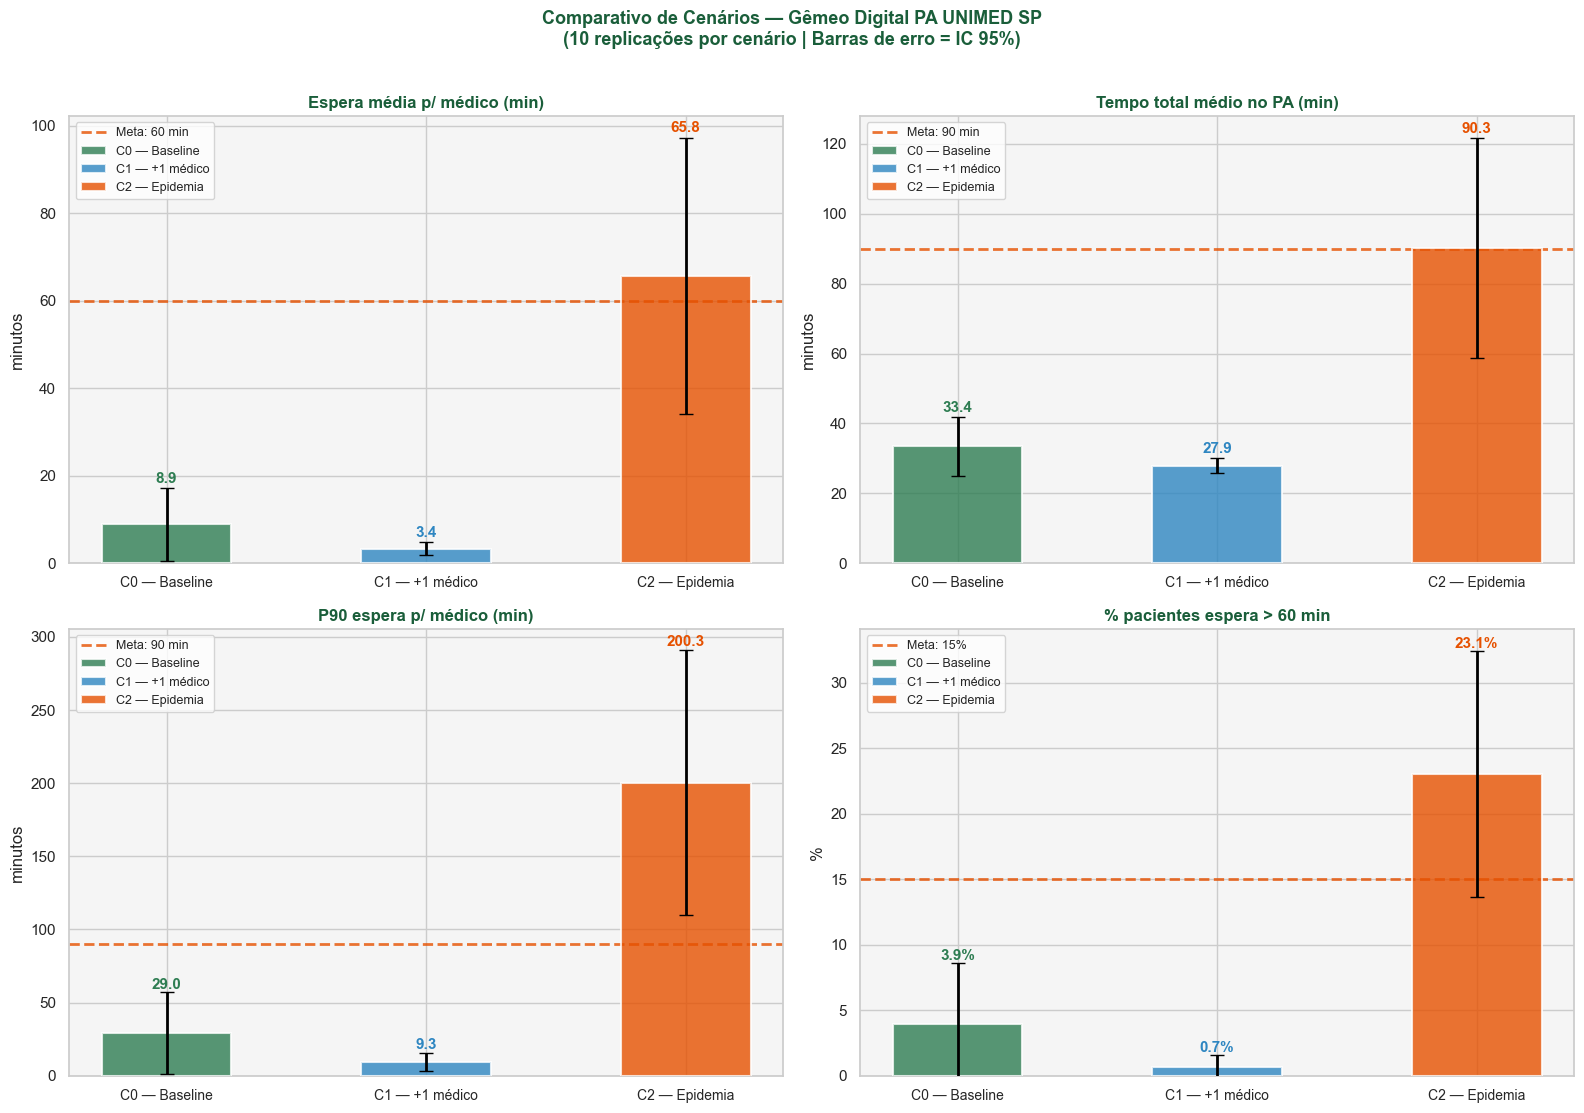

📊  Figura 3 gerada


In [75]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 15 — Visualização comparativa dos cenários
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

kpis_comparar = [
    ("espera_medico_media", "Espera média p/ médico (min)", 60, "min"),
    ("tempo_total_medio", "Tempo total médio no PA (min)", 90, "min"),
    ("p90_espera_medico", "P90 espera p/ médico (min)", 90, "min"),
    ("pct_espera_acima_60", "% pacientes espera > 60 min", 0.15, "pct"),
]
cores_cen = [VERDE2, AZUL2, LARANJA]
nomes_cen = list(resultados_cenarios.keys())
nomes_curtos = rotulos_cenarios_curtos

for ax, (col, titulo, meta, tipo) in zip(axes, kpis_comparar):
    x = np.arange(len(nomes_cen))
    w = 0.5

    for i, (nome, df_c, cor) in enumerate(
        zip(nomes_curtos, resultados_cenarios.values(), cores_cen)
    ):
        vals = df_c[col] * (100 if tipo == "pct" else 1)
        m, lo, hi = ic95(vals)
        bar = ax.bar(
            i,
            m,
            w,
            color=cor,
            alpha=0.80,
            edgecolor="white",
            linewidth=1.5,
            label=nome,
            zorder=3,
        )
        ax.errorbar(
            i,
            m,
            yerr=[[m - lo], [hi - m]],
            fmt="none",
            color="black",
            capsize=5,
            linewidth=2,
            zorder=4,
        )
        ax.text(
            i,
            hi + (0.5 if tipo != "pct" else 0.002),
            f"{m:.1f}{'%' if tipo=='pct' else ''}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=cor,
        )

    meta_val = meta * (100 if tipo == "pct" else 1)
    ax.axhline(
        meta_val,
        color=LARANJA,
        linewidth=2,
        linestyle="--",
        alpha=0.8,
        label=f"Meta: {meta_val:.0f}{'%' if tipo=='pct' else ' min'}",
    )
    ax.set_title(titulo, fontweight="bold", color=VERDE)
    ax.set_xticks(x)
    ax.set_xticklabels(nomes_curtos, fontsize=10)
    ax.set_ylabel("%" if tipo == "pct" else "minutos")
    ax.legend(fontsize=9)
    ax.set_facecolor(CINZA)
    ax.set_ylim(bottom=0)

fig.suptitle(
    "Comparativo de Cenários — Gêmeo Digital PA UNIMED SP\n(10 replicações por cenário | Barras de erro = IC 95%)",
    fontsize=13,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig3_cenarios.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura 3 gerada")

### 🔍 Como interpretar o comparativo

**Cenário 1 — +1 médico no turno vespertino (13h–19h):**

- compare a redução esperada de espera com o custo de reforço;
- observe se a melhora aparece só na média ou também na cauda (`P90` e `% > 60 min`);
- use este cenário para discutir **trade-off entre serviço e custo**.

**Cenário 2 — epidemia (+40% de demanda):**

- observe o quanto a fila cresce quando a demanda pressiona a mesma capacidade;
- verifique se o aumento afeta só a média ou também os extremos da distribuição;
- trate este cenário como ensaio de **resiliência operacional**.

> 📌 **Leitura correta desta etapa:** use o último checkpoint metodológico impresso acima para decidir se estes resultados já estão liberados para decisão real ou se ainda devem ser lidos como contraste relativo entre políticas e choques.


---

## Painel Integrado — Leitura gerencial da Etapa 7

**O que está sendo feito:** consolidar, em um único painel, o comportamento do twin sob baseline, cenários e parâmetros observados.

**Como interpretar:** este dashboard organiza a conversa gerencial. O status metodológico a usar aqui é o do checkpoint mais recente de validação/recalibração exibido acima.


/var/folders/qy/v482m2215v59dlznrv8yyrp80000gn/T/ipykernel_90578/2074301896.py:243: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig("d10_fig4_dashboard.png", dpi=130, bbox_inches="tight")
/var/folders/qy/v482m2215v59dlznrv8yyrp80000gn/T/ipykernel_90578/2074301896.py:243: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig("d10_fig4_dashboard.png", dpi=130, bbox_inches="tight")
/var/folders/qy/v482m2215v59dlznrv8yyrp80000gn/T/ipykernel_90578/2074301896.py:243: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("d10_fig4_dashboard.png", dpi=130, bbox_inches="tight")
/Users/pedroeckel/gestao_quanti/projects/unimed sp/code/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pedroeckel/gestao_quanti/projects/unimed sp/code/.venv/l

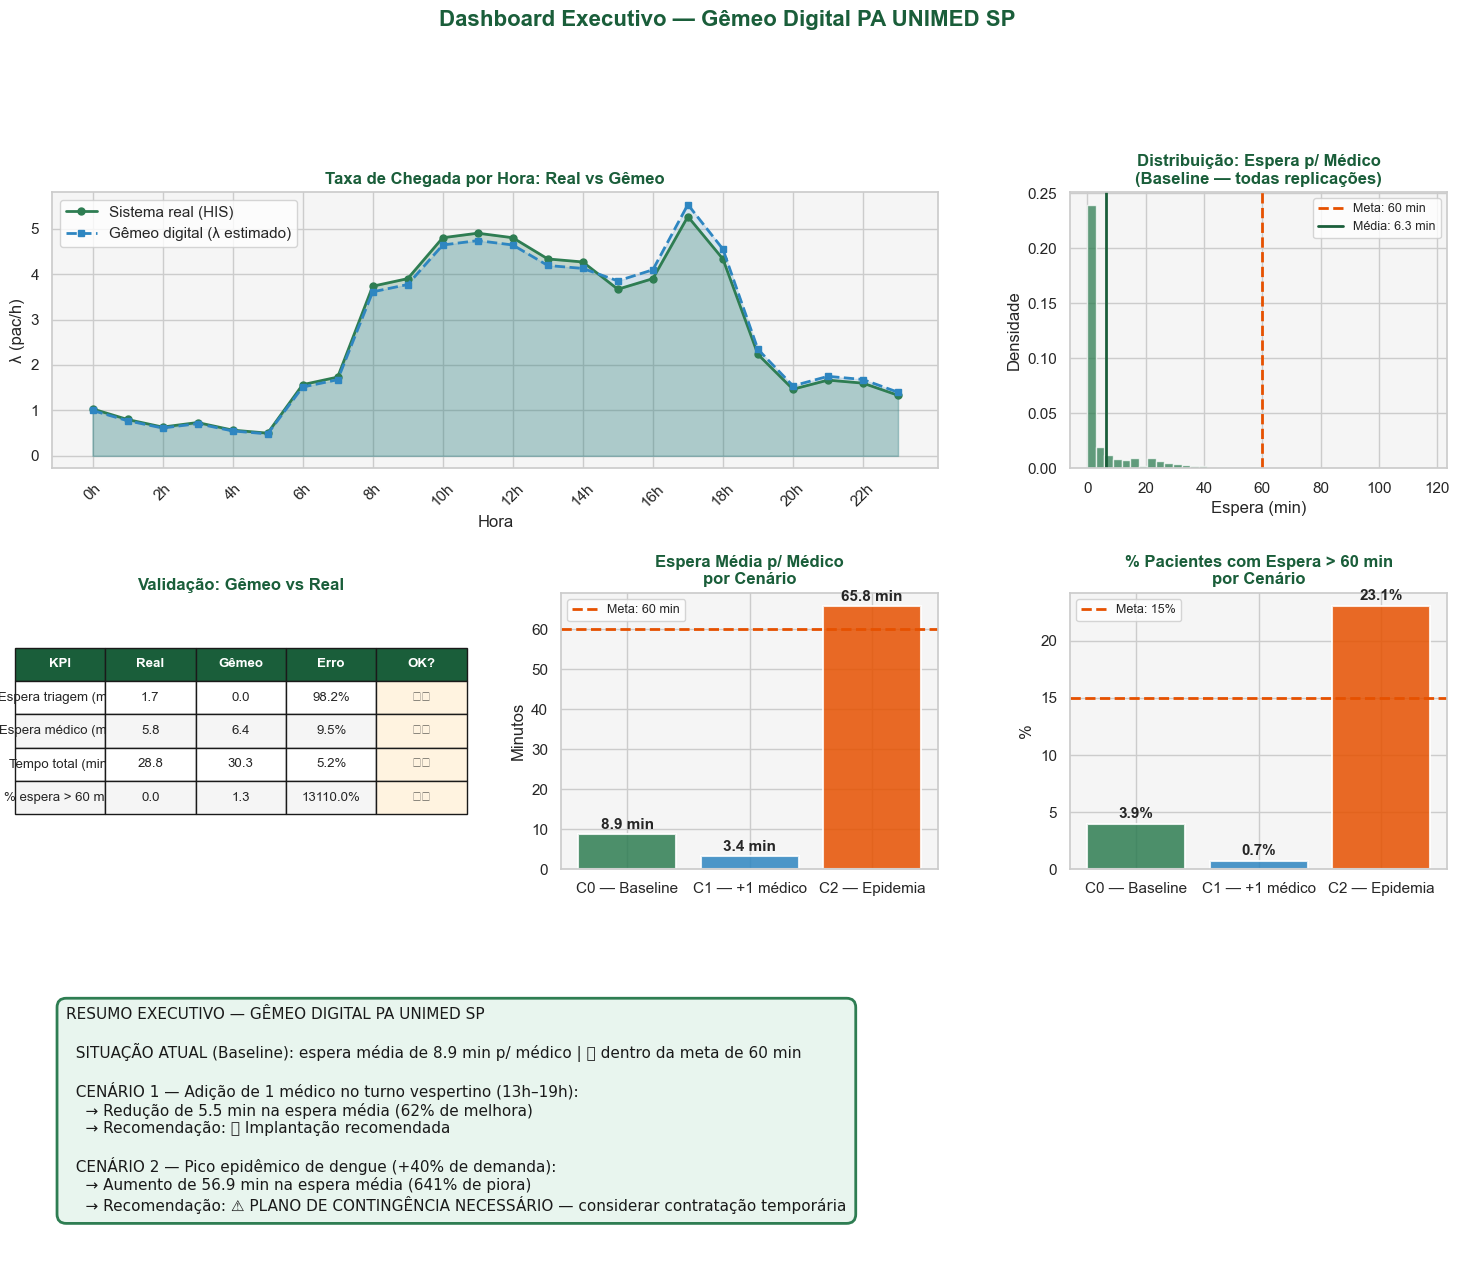

📊  Dashboard final gerado — Figura 4


In [76]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 16 — Dashboard executivo completo
# ─────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Painel 1: λ por hora (dados reais vs gêmeo) ────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
horas = list(range(24))
lam_real = [df_clean.groupby("hora").size()[h] / 30 for h in horas]
lam_gemeo = [PARAMS_GEMEO["lambda_hora"].get(h, 0) for h in horas]
ax1.fill_between(horas, lam_real, alpha=0.25, color=VERDE2)
ax1.fill_between(horas, lam_gemeo, alpha=0.15, color=AZUL2)
ax1.plot(
    horas,
    lam_real,
    "-o",
    color=VERDE2,
    linewidth=2,
    markersize=5,
    label="Sistema real (HIS)",
)
ax1.plot(
    horas,
    lam_gemeo,
    "--s",
    color=AZUL2,
    linewidth=2,
    markersize=5,
    label="Gêmeo digital (λ estimado)",
)
ax1.set_title("Taxa de Chegada por Hora: Real vs Gêmeo", fontweight="bold", color=VERDE)
ax1.set_xlabel("Hora")
ax1.set_ylabel("λ (pac/h)")
ax1.set_xticks(range(0, 24, 2))
ax1.set_xticklabels([f"{h}h" for h in range(0, 24, 2)], rotation=45)
ax1.legend()
ax1.set_facecolor(CINZA)

# ── Painel 2: Distribuição dos tempos de espera (baseline) ────
ax2 = fig.add_subplot(gs[0, 2])
df_base_result = pd.concat(resultados_reps[:10], ignore_index=True)
ax2.hist(
    df_base_result.espera_medico.clip(0, 120),
    bins=40,
    density=True,
    color=VERDE2,
    alpha=0.75,
    edgecolor="white",
)
ax2.axvline(60, color=LARANJA, linewidth=2, linestyle="--", label="Meta: 60 min")
ax2.axvline(
    df_base_result.espera_medico.mean(),
    color=VERDE,
    linewidth=2,
    label=f"Média: {df_base_result.espera_medico.mean():.1f} min",
)
ax2.set_title(
    "Distribuição: Espera p/ Médico\n(Baseline — todas replicações)",
    fontweight="bold",
    color=VERDE,
)
ax2.set_xlabel("Espera (min)")
ax2.set_ylabel("Densidade")
ax2.legend(fontsize=9)
ax2.set_facecolor(CINZA)

# ── Painel 3: Tabela de validação visual ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis("off")
kpis_val = [
    (
        "Espera triagem (min)",
        kpis_reais.get("espera_triagem_media", df_clean.t_triagem_min.mean()),
        IC_FINAL.get("espera_triagem_media", {}).get("media", 0),
    ),
    (
        "Espera médico (min)",
        kpis_reais["espera_medico_media"],
        IC_FINAL["espera_medico_media"]["media"],
    ),
    (
        "Tempo total (min)",
        kpis_reais["tempo_total_medio"],
        IC_FINAL["tempo_total_medio"]["media"],
    ),
    (
        "% espera > 60 min",
        kpis_reais["pct_espera_acima_60"] * 100,
        IC_FINAL["pct_espera_acima_60"]["media"] * 100,
    ),
]
tabela_data = []
for nome, real, sim in kpis_val:
    erro = abs(sim - real) / max(abs(real), 0.01) * 100
    tabela_data.append(
        [nome, f"{real:.1f}", f"{sim:.1f}", f"{erro:.1f}%", "✅" if erro < 5 else "⚠️"]
    )

tbl = ax3.table(
    cellText=tabela_data,
    colLabels=["KPI", "Real", "Gêmeo", "Erro", "OK?"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.2, 2.0)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(VERDE)
        cell.set_text_props(color="white", weight="bold")
    elif col == 4:
        cell.set_facecolor(
            "#E8F5EE" if "✅" in cell.get_text().get_text() else "#FFF3E0"
        )
    elif row % 2 == 0:
        cell.set_facecolor("#F5F5F5")
ax3.set_title("Validação: Gêmeo vs Real", fontweight="bold", color=VERDE, y=0.98)

# ── Painel 4: Comparativo de cenários (espera médico) ────────
ax4 = fig.add_subplot(gs[1, 1])
nomes_curtos = rotulos_cenarios_curtos
medias_em = [
    resultados_cenarios[n].espera_medico_media.mean() for n in resultados_cenarios
]
cores_bar = [VERDE2, AZUL2, LARANJA]
bars = ax4.bar(
    nomes_curtos,
    medias_em,
    color=cores_bar,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
ax4.axhline(60, color=LARANJA, linewidth=2, linestyle="--", label="Meta: 60 min")
for bar, val in zip(bars, medias_em):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        f"{val:.1f} min",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )
ax4.set_title("Espera Média p/ Médico\npor Cenário", fontweight="bold", color=VERDE)
ax4.set_ylabel("Minutos")
ax4.legend(fontsize=9)
ax4.set_facecolor(CINZA)

# ── Painel 5: Comparativo % > 60 min ─────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
medias_pct = [
    resultados_cenarios[n].pct_espera_acima_60.mean() * 100 for n in resultados_cenarios
]
bars5 = ax5.bar(
    nomes_curtos,
    medias_pct,
    color=cores_bar,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
ax5.axhline(15, color=LARANJA, linewidth=2, linestyle="--", label="Meta: 15%")
for bar, val in zip(bars5, medias_pct):
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )
ax5.set_title(
    "% Pacientes com Espera > 60 min\npor Cenário", fontweight="bold", color=VERDE
)
ax5.set_ylabel("%")
ax5.legend(fontsize=9)
ax5.set_facecolor(CINZA)

# ── Painel 6: Resumo executivo (texto) ────────────────────────
ax6 = fig.add_subplot(gs[2, :])
ax6.axis("off")
em0 = resultados_cenarios[
    list(resultados_cenarios.keys())[0]
].espera_medico_media.mean()
em1 = resultados_cenarios[
    list(resultados_cenarios.keys())[1]
].espera_medico_media.mean()
em2 = resultados_cenarios[
    list(resultados_cenarios.keys())[2]
].espera_medico_media.mean()
delta_1 = em0 - em1
delta_2 = em2 - em0

meta_baseline = (
    "✅ dentro da meta de 60 min" if em0 < 60 else "⚠️ ACIMA da meta de 60 min"
)
rec1 = (
    "✅ Implantação recomendada"
    if delta_1 > 3
    else "ℹ️ Ganho marginal — reavaliar custo-benefício"
)
rec2 = (
    "⚠️ PLANO DE CONTINGÊNCIA NECESSÁRIO — considerar contratação temporária"
    if em2 > 60
    else "✅ PA consegue absorver o pico com escala atual"
)
resumo = (
    "RESUMO EXECUTIVO — GÊMEO DIGITAL PA UNIMED SP\n\n"
    f"  SITUAÇÃO ATUAL (Baseline): espera média de {em0:.1f} min p/ médico | {meta_baseline}\n\n"
    f"  CENÁRIO 1 — Adição de 1 médico no turno vespertino (13h–19h):\n"
    f"    → Redução de {delta_1:.1f} min na espera média ({delta_1/em0*100:.0f}% de melhora)\n"
    f"    → Recomendação: {rec1}\n\n"
    f"  CENÁRIO 2 — Pico epidêmico de dengue (+40% de demanda):\n"
    f"    → Aumento de {delta_2:.1f} min na espera média ({delta_2/em0*100:.0f}% de piora)\n"
    f"    → Recomendação: {rec2}"
)
ax6.text(
    0.01,
    0.95,
    resumo,
    transform=ax6.transAxes,
    fontsize=11,
    verticalalignment="top",
    fontfamily="DejaVu Sans",
    bbox=dict(
        boxstyle="round,pad=0.6", facecolor="#E8F5EE", edgecolor=VERDE2, linewidth=2
    ),
    color="#1A1A1A",
)

fig.suptitle(
    "Dashboard Executivo — Gêmeo Digital PA UNIMED SP",
    fontsize=16,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.savefig("d10_fig4_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Dashboard final gerado — Figura 4")

---

## Etapa 7B — Antecipar demanda com predição

**Pergunta gerencial desta etapa:** o que tende a acontecer com o PA nos próximos 14 dias se o padrão de demanda se mantiver?

**O que está sendo feito:** projetar a demanda diária dos próximos 14 dias e converter essa projeção em pressão operacional sobre o twin.

**Por que isso importa:** um twin maduro não apenas replica o presente; ele antecipa gargalos antes que eles aconteçam.

**Como interpretar:** primeiro leia a previsão de volume; depois observe como ela altera os KPIs esperados do sistema.

**O que isso habilita na sequência:** separar duas leituras complementares: primeiro **o que tende a acontecer** e, na etapa seguinte, **o que fazer** diante desse futuro antecipado.

> 📌 **Status metodológico:** a leitura desta predição depende do checkpoint mais recente de validação/recalibração. Confira o contexto impresso na célula seguinte antes de tratá-la como forecast operacional.

### 📐 Por que usar Prophet aqui?

O Prophet permite separar tendência, sazonalidade semanal e incerteza para montar um horizonte simples de 14 dias. O ganho didático não é “acertar o futuro com perfeição”, mas mostrar como a previsão de volume altera `λ` e, com isso, os KPIs simulados.

> 🔗 **Transição para a próxima etapa:** aqui respondemos **o que tende a acontecer**; na prescrição, responderemos **o que fazer** quando esse futuro pressiona o sistema.

> ⚠️ Com apenas 30 dias históricos, este ajuste é deliberadamente enxuto. Em produção, o ideal é usar uma janela maior de dados.


19:14:38 - cmdstanpy - INFO - Chain [1] start processing
19:14:38 - cmdstanpy - INFO - Chain [1] done processing


📌 Contexto desta etapa: uso apenas ilustrativo até recalibração adicional
   A previsão abaixo mostra como o volume futuro pode ser transformado em pressão de demanda no twin.

📅  Série histórica: 30 dias
   De: 2024-11-01  Até: 2024-11-30
   Média diária: 64 pac/dia
   Máximo: 79  |  Mínimo: 43

✅  Prophet treinado!
📅  Previsão: 2024-12-01 → 2024-12-14

📊  Resumo da previsão para os próximos 14 dias:
   Média prevista : 70 pac/dia
   IC 95%         : [57, 84] pac/dia
   Dia mais crítico: Tuesday 10/12 (78 pac)
   Dia mais tranquilo: Saturday 07/12 (61 pac)


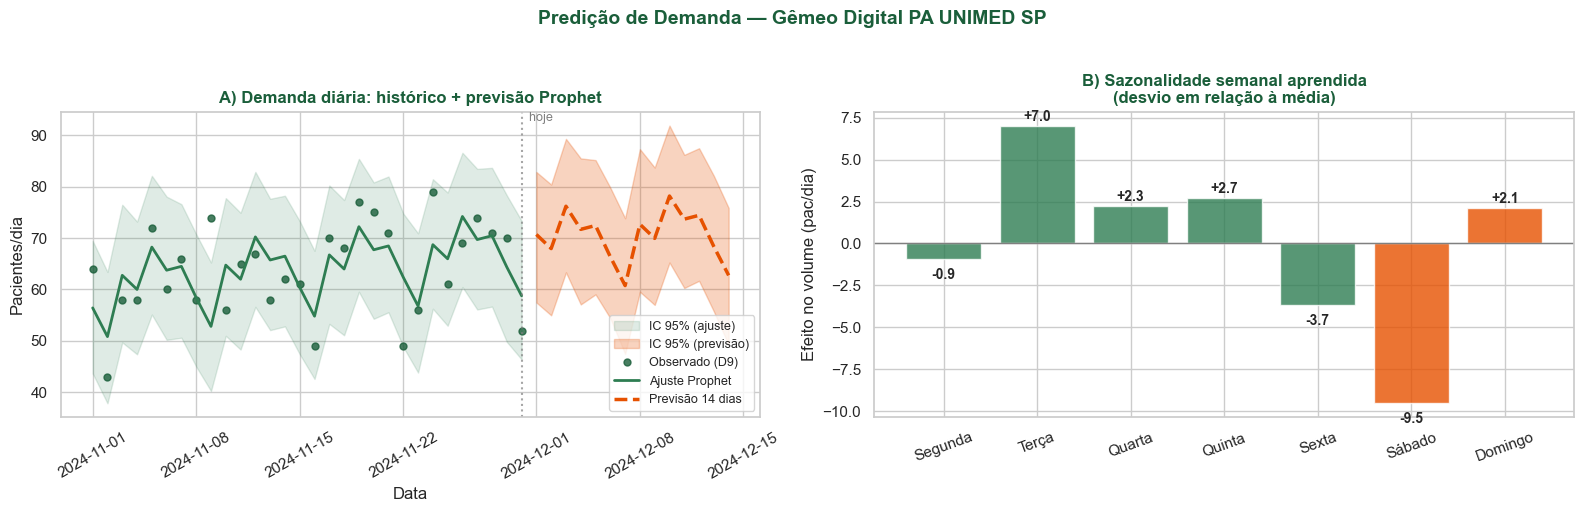

📊  Figura Prophet gerada


In [77]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 17 — Predição de demanda com Prophet
# Usa o histórico de 30 dias para prever os próximos 14 dias
# ─────────────────────────────────────────────────────────────────

print(f"📌 Contexto desta etapa: {contexto_uso_gemeo}")
print(
    "   A previsão abaixo mostra como o volume futuro pode ser transformado em pressão de demanda no twin.\n"
)

# ── Prepara série temporal diária (formato exigido pelo Prophet) ─
df_prophet = (
    df_clean.groupby(df_clean.dt_chegada.dt.date)
    .size()
    .reset_index(name="y")
    .rename(columns={"dt_chegada": "ds"})
)
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

print(f"📅  Série histórica: {len(df_prophet)} dias")
print(f"   De: {df_prophet.ds.min().date()}  Até: {df_prophet.ds.max().date()}")
print(f"   Média diária: {df_prophet.y.mean():.0f} pac/dia")
print(f"   Máximo: {df_prophet.y.max():.0f}  |  Mínimo: {df_prophet.y.min():.0f}")

modelo_prophet = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.95,
)
modelo_prophet.fit(df_prophet)

futuro = modelo_prophet.make_future_dataframe(periods=14)
previsao = modelo_prophet.predict(futuro)

corte = df_prophet.ds.max()
prev_hist = previsao[previsao.ds <= corte].copy()
prev_futura = previsao[previsao.ds > corte].copy()

print(f"\n✅  Prophet treinado!")
print(f"📅  Previsão: {prev_futura.ds.min().date()} → {prev_futura.ds.max().date()}")
print(f"\n📊  Resumo da previsão para os próximos 14 dias:")
print(f"   Média prevista : {prev_futura.yhat.mean():.0f} pac/dia")
print(
    f"   IC 95%         : [{prev_futura.yhat_lower.mean():.0f}, {prev_futura.yhat_upper.mean():.0f}] pac/dia"
)
print(
    f"   Dia mais crítico: {prev_futura.loc[prev_futura.yhat.idxmax(), 'ds'].strftime('%A %d/%m')} "
    f"({prev_futura.yhat.max():.0f} pac)"
)
print(
    f"   Dia mais tranquilo: {prev_futura.loc[prev_futura.yhat.idxmin(), 'ds'].strftime('%A %d/%m')} "
    f"({prev_futura.yhat.min():.0f} pac)"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.fill_between(
    prev_hist.ds,
    prev_hist.yhat_lower,
    prev_hist.yhat_upper,
    alpha=0.15,
    color=VERDE2,
    label="IC 95% (ajuste)",
)
ax.fill_between(
    prev_futura.ds,
    prev_futura.yhat_lower,
    prev_futura.yhat_upper,
    alpha=0.25,
    color=LARANJA,
    label="IC 95% (previsão)",
)
ax.plot(
    df_prophet.ds,
    df_prophet.y,
    "o",
    color=VERDE,
    markersize=5,
    alpha=0.8,
    label="Observado (D9)",
)
ax.plot(
    prev_hist.ds, prev_hist.yhat, "-", color=VERDE2, linewidth=2, label="Ajuste Prophet"
)
ax.plot(
    prev_futura.ds,
    prev_futura.yhat,
    "--",
    color=LARANJA,
    linewidth=2.5,
    label="Previsão 14 dias",
)
ax.axvline(corte, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax.text(
    corte,
    ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 160,
    "  hoje",
    fontsize=9,
    color="gray",
    va="top",
)
ax.set_title(
    "A) Demanda diária: histórico + previsão Prophet", fontweight="bold", color=VERDE
)
ax.set_xlabel("Data")
ax.set_ylabel("Pacientes/dia")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

ax2 = axes[1]
comp = modelo_prophet.predict(
    pd.DataFrame({"ds": pd.date_range("2024-11-04", periods=7)})
)
dias_ptbr = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]
weekly_comp = comp["weekly"].values
cores_dias = [VERDE2] * 5 + [LARANJA] * 2
bars = ax2.bar(dias_ptbr, weekly_comp, color=cores_dias, alpha=0.8, edgecolor="white")
ax2.axhline(0, color="gray", linewidth=1)
for bar, val in zip(bars, weekly_comp):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + (0.3 if val >= 0 else -1.2),
        f"{val:+.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
ax2.set_title(
    "B) Sazonalidade semanal aprendida\n(desvio em relação à média)",
    fontweight="bold",
    color=VERDE,
)
ax2.set_ylabel("Efeito no volume (pac/dia)")
ax2.tick_params(axis="x", rotation=20)

fig.suptitle(
    "Predição de Demanda — Gêmeo Digital PA UNIMED SP",
    fontsize=14,
    fontweight="bold",
    color=VERDE,
    y=1.02,
)
plt.tight_layout()
plt.savefig("d10_fig6_predicao.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura Prophet gerada")

📌 Contexto desta etapa: uso apenas ilustrativo até recalibração adicional
   O objetivo aqui é transformar previsão de volume em pressão operacional prevista.

  Data         Dia        Prev (pac)    Fator λ  Espera est.
  01/12/2024   Dom            71 pac      1.11x        4.6 min ✅
  02/12/2024   Seg            68 pac      1.07x       24.8 min ✅
  03/12/2024   Ter            76 pac      1.19x       13.7 min ✅
  04/12/2024   Qua            72 pac      1.12x        4.9 min ✅
  05/12/2024   Qui            72 pac      1.14x        4.8 min ✅
  06/12/2024   Sex            66 pac      1.04x        7.5 min ✅
  07/12/2024   Sáb            61 pac      0.95x        7.5 min ✅
  08/12/2024   Dom            73 pac      1.14x       14.2 min ✅
  09/12/2024   Seg            70 pac      1.10x       17.7 min ✅
  10/12/2024   Ter            78 pac      1.23x       29.1 min ✅
  11/12/2024   Qua            74 pac      1.16x       26.9 min ✅
  12/12/2024   Qui            74 pac      1.17x       19.5 min ✅

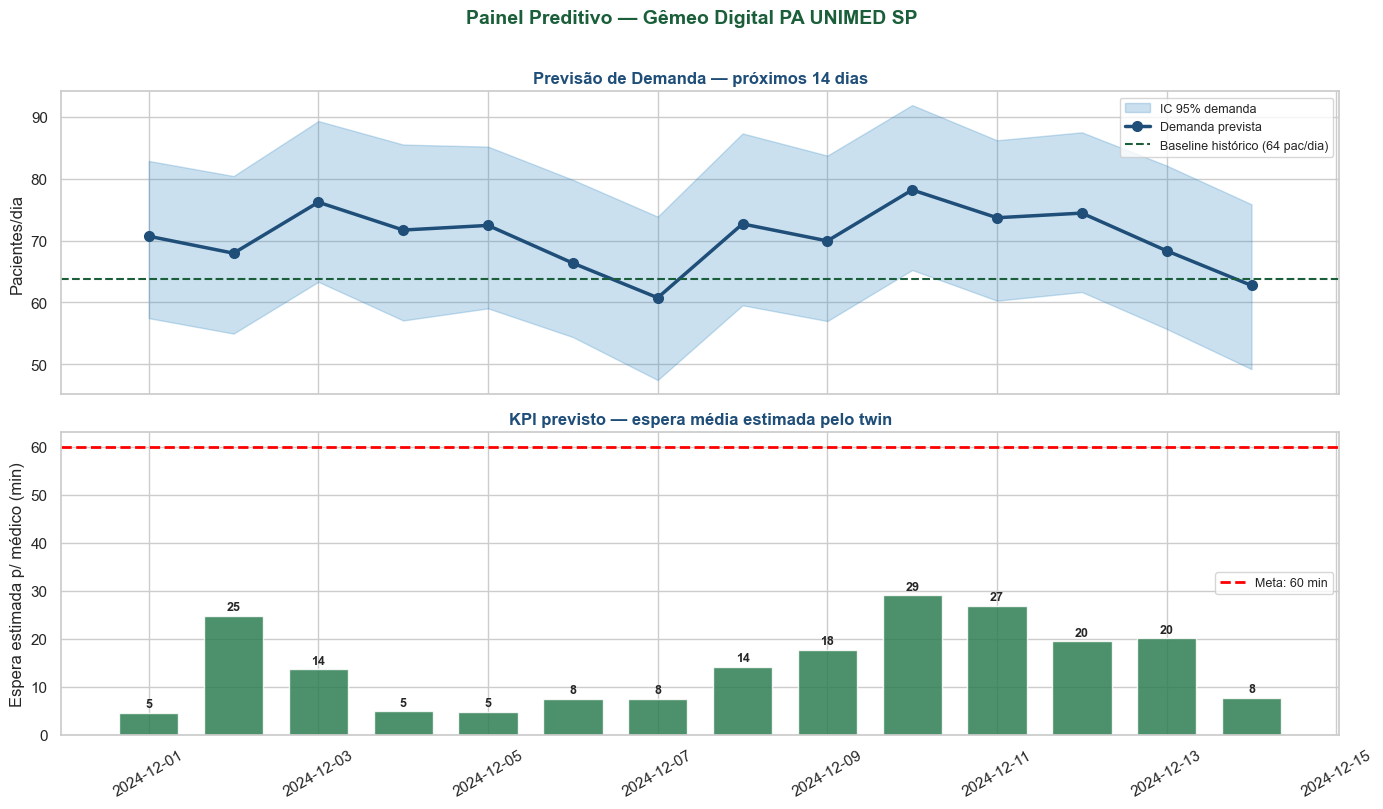

📊  Painel preditivo gerado — Figura 6


In [78]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 18 — Simulador com λ previsto: KPIs antecipados
# ─────────────────────────────────────────────────────────────────

from scipy.stats import t as t_dist

print(f"📌 Contexto desta etapa: {contexto_uso_gemeo}")
print(
    "   O objetivo aqui é transformar previsão de volume em pressão operacional prevista.\n"
)

demanda_baseline = df_prophet.y.mean()

print("=" * 60)
print(
    f"  {'Data':<12} {'Dia':<10} {'Prev (pac)':<12} {'Fator λ':>8} {'Espera est.':>12}"
)
print("=" * 60)

resultados_predicao = []

for _, row in prev_futura.iterrows():
    fator = row["yhat"] / demanda_baseline
    fator_lo = row["yhat_lower"] / demanda_baseline
    fator_hi = row["yhat_upper"] / demanda_baseline

    params_prev = {**PARAMS_GEMEO}
    params_prev["lambda_hora"] = {
        h: v * fator for h, v in PARAMS_GEMEO["lambda_hora"].items()
    }

    np.random.seed(int(row["ds"].timestamp()) % 10000)
    _, estat_dia = gemeo_digital_pa(
        params_prev, semente=42, duracao_min=24 * 60, warmup_min=4 * 60
    )
    em_est = estat_dia["espera_medico_media"]

    dia_nome = (
        row["ds"]
        .strftime("%a")
        .replace("Mon", "Seg")
        .replace("Tue", "Ter")
        .replace("Wed", "Qua")
        .replace("Thu", "Qui")
        .replace("Fri", "Sex")
        .replace("Sat", "Sáb")
        .replace("Sun", "Dom")
    )

    flag = " ⚠️" if em_est > 60 else " ✅"
    print(
        f"  {row['ds'].strftime('%d/%m/%Y'):<12} {dia_nome:<10} "
        f"{row['yhat']:>6.0f} pac    {fator:>6.2f}x   {em_est:>8.1f} min{flag}"
    )

    resultados_predicao.append(
        {
            "ds": row["ds"],
            "yhat": row["yhat"],
            "yhat_lower": row["yhat_lower"],
            "yhat_upper": row["yhat_upper"],
            "fator": fator,
            "fator_lo": fator_lo,
            "fator_hi": fator_hi,
            "espera_est": em_est,
        }
    )

print("=" * 60)
print("Legenda: ✅ espera ≤ 60 min (dentro da meta)  |  ⚠️ espera > 60 min")

df_pred = pd.DataFrame(resultados_predicao)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(
    df_pred.ds,
    df_pred.yhat_lower,
    df_pred.yhat_upper,
    alpha=0.25,
    color=AZUL2,
    label="IC 95% demanda",
)
ax1.plot(
    df_pred.ds,
    df_pred.yhat,
    "o-",
    color=AZUL,
    linewidth=2.5,
    markersize=7,
    label="Demanda prevista",
)
ax1.axhline(
    demanda_baseline,
    color=VERDE,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline histórico ({demanda_baseline:.0f} pac/dia)",
)
ax1.set_ylabel("Pacientes/dia")
ax1.set_title("Previsão de Demanda — próximos 14 dias", fontweight="bold", color=AZUL)
ax1.legend(fontsize=9)

ax2 = axes[1]
cores_barra = [LARANJA if v > 60 else VERDE2 for v in df_pred.espera_est]
bars = ax2.bar(
    df_pred.ds,
    df_pred.espera_est,
    color=cores_barra,
    alpha=0.85,
    edgecolor="white",
    width=0.7,
)
ax2.axhline(60, color="red", linestyle="--", linewidth=2, label="Meta: 60 min")
for bar, val in zip(bars, df_pred.espera_est):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax2.set_ylabel("Espera estimada p/ médico (min)")
ax2.set_title(
    "KPI previsto — espera média estimada pelo twin",
    fontweight="bold",
    color=AZUL,
)
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=30)

n_criticos = (df_pred.espera_est > 60).sum()
print(f"\n⚡  Alerta: {n_criticos} de 14 dias previstos com espera > 60 min")
if n_criticos > 0:
    dias_crit = df_pred[df_pred.espera_est > 60].ds.dt.strftime("%d/%m").tolist()
    print(f"   Dias críticos: {', '.join(dias_crit)}")
    print("   → Recomendação: considerar reforço de escala nesses dias.")
else:
    print(
        "   → No horizonte previsto, a demanda base ainda não aciona reforço pela meta de 60 min."
    )
print(
    "   → Aqui a predição responde o que tende a acontecer; a próxima etapa perguntará o que fazer quando o stress ativa restrições."
)

fig.suptitle(
    "Painel Preditivo — Gêmeo Digital PA UNIMED SP",
    fontsize=14,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig5_prophet.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Painel preditivo gerado — Figura 6")

---

## Etapa 8 — Apoiar decisão com prescrição

**Pergunta gerencial desta etapa:** qual reforço mínimo vale o custo para proteger o nível de serviço nos dias críticos?

**O que está sendo feito:** transformar leitura preditiva em recomendação operacional de escala.

**Por que isso importa:** a camada prescritiva responde à pergunta final do módulo: **o que fazer** diante do comportamento previsto do sistema?

**Como interpretar:** nesta entrega, a prescrição será lida como **stress test gerencial ilustrativo**. Mantemos a previsão base para a leitura preditiva e criamos uma demanda mais severa nos dias críticos para ativar restrições e trade-offs reais de escala.

**O que isso consolida:** o framework completo do twin, do dado histórico à decisão apoiada por otimização.

**Ao final desta etapa, você deve ser capaz de:** ler a recomendação como trade-off entre custo adicional de escala e preservação do nível de serviço.

**O que observar nesta etapa:** quais dias e turnos pedem reforço, quanto a espera cai e onde a restrição realmente fica ativa.

### Formulação didática desta etapa

- **Entrada base:** previsão de 14 dias gerada pelo Prophet.
- **Entrada prescritiva:** versão estressada da demanda nos dias mais críticos, apenas para fins didáticos.
- **Políticas candidatas:** combinações discretas de médicos extras nos turnos `matutino`, `vespertino` e `noturno2`.
- **Objetivo:** encontrar o menor reforço capaz de atender às metas de serviço no stress test.

> ⚠️ **Importante:** este bloco não “corrige” a falta de validação. Ele mostra como a camada prescritiva deve funcionar depois que o twin for recalibrado e validado.


In [79]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 19 — Otimização prescritiva da escala com Pyomo
# Usa um stress test didático sobre os dias mais críticos para
# forçar trade-offs reais entre custo e nível de serviço.
# ─────────────────────────────────────────────────────────────────

from itertools import product
import copy
import pyomo.environ as pyo

META_ESPERA_MEDICO = 60.0
META_PCT_ESPERA_60 = 0.15
TURNOS_OTIM = ["matutino", "vespertino", "noturno2"]
CUSTO_TURNO = {"matutino": 1.0, "vespertino": 1.0, "noturno2": 1.2}
GRADE_REFORCO = list(product(range(0, 2), range(0, 3), range(0, 2)))
N_REP_OTIM = 4

print(f"📌 Contexto desta etapa: {contexto_uso_gemeo}")
print(
    "   A otimização abaixo usa um stress test gerencial ilustrativo para ativar trade-offs reais.\n"
)

df_pred_presc = df_pred.copy()
df_pred_presc["rank_criticidade"] = df_pred_presc["yhat"].rank(
    method="first", ascending=False
)
df_pred_presc["multiplicador_estresse"] = np.where(
    df_pred_presc["rank_criticidade"] <= 4,
    2.00,
    np.where(df_pred_presc["rank_criticidade"] <= 8, 1.75, 1.55),
)
df_pred_presc["yhat_estresse"] = (
    df_pred_presc["yhat"] * df_pred_presc["multiplicador_estresse"]
)
df_pred_presc["fator_prescritivo"] = (
    df_pred_presc["fator"] * df_pred_presc["multiplicador_estresse"]
)

print("🔬 Stress test prescritivo aplicado sobre a previsão base:")
tabela_estresse = df_pred_presc[
    ["ds", "yhat", "yhat_estresse", "multiplicador_estresse", "fator_prescritivo"]
].copy()
tabela_estresse["ds"] = tabela_estresse["ds"].dt.strftime("%d/%m")
tabela_estresse = tabela_estresse.rename(
    columns={
        "ds": "Data",
        "yhat": "Dem. base",
        "yhat_estresse": "Dem. stress",
        "multiplicador_estresse": "Multiplicador",
        "fator_prescritivo": "Fator λ stress",
    }
)
print(tabela_estresse.round(1).to_string(index=False))
print()

SOLVER_PYOMO = None
for nome_solver in ["appsi_highs", "highs"]:
    solver = pyo.SolverFactory(nome_solver)
    try:
        disponivel = bool(solver.available(False))
    except Exception:
        disponivel = False
    if disponivel:
        SOLVER_PYOMO = nome_solver
        break

if SOLVER_PYOMO is None:
    raise RuntimeError(
        "Nenhum solver compatível com Pyomo foi encontrado. Instale highspy/HiGHS."
    )

print(f"🔧 Solver Pyomo selecionado: {SOLVER_PYOMO}")


def avaliar_politica_prescritiva(fator_demanda, reforco_turno, seed_base=900):
    params = copy.deepcopy(PARAMS_GEMEO)
    params["lambda_hora"] = {
        h: v * fator_demanda for h, v in PARAMS_GEMEO["lambda_hora"].items()
    }
    for turno, acrescimo in reforco_turno.items():
        params["recursos_turno"][turno]["medicos"] += acrescimo

    estats = []
    for rep in range(N_REP_OTIM):
        _, estat = gemeo_digital_pa(
            params,
            semente=seed_base + rep,
            duracao_min=24 * 60,
            warmup_min=4 * 60,
        )
        if estat:
            estats.append(estat)

    df_eval = pd.DataFrame(estats)
    espera_media = df_eval["espera_medico_media"].mean()
    pct_espera_60 = df_eval["pct_espera_acima_60"].mean()
    extra_total = sum(reforco_turno.values())
    custo_relativo = sum(reforco_turno[t] * CUSTO_TURNO[t] for t in TURNOS_OTIM)
    atinge_meta = (espera_media <= META_ESPERA_MEDICO) and (
        pct_espera_60 <= META_PCT_ESPERA_60
    )

    return {
        "espera_pos": espera_media,
        "pct_pos": pct_espera_60,
        "extra_total": extra_total,
        "custo_relativo": custo_relativo,
        "atinge_meta": atinge_meta,
        "violacao_total": max(0.0, espera_media - META_ESPERA_MEDICO)
        + 100 * max(0.0, pct_espera_60 - META_PCT_ESPERA_60),
    }


def resolver_politica_pyomo(df_cand):
    model = pyo.ConcreteModel()
    idxs = list(df_cand.index)
    model.K = pyo.Set(initialize=idxs)
    model.y = pyo.Var(model.K, domain=pyo.Binary)

    espera = df_cand["espera_pos"].to_dict()
    pct = df_cand["pct_pos"].to_dict()
    custo = df_cand["custo_relativo"].to_dict()
    extra = df_cand["extra_total"].to_dict()

    model.obj = pyo.Objective(
        expr=sum(
            (1000 * custo[k] + extra[k] + espera[k] / 1000) * model.y[k]
            for k in model.K
        ),
        sense=pyo.minimize,
    )
    model.escolher_uma = pyo.Constraint(expr=sum(model.y[k] for k in model.K) == 1)
    model.meta_espera = pyo.Constraint(
        expr=sum(espera[k] * model.y[k] for k in model.K) <= META_ESPERA_MEDICO
    )
    model.meta_pct = pyo.Constraint(
        expr=sum(pct[k] * model.y[k] for k in model.K) <= META_PCT_ESPERA_60
    )

    solver = pyo.SolverFactory(SOLVER_PYOMO)
    try:
        resultado = solver.solve(model)
        status = str(resultado.solver.termination_condition)
    except RuntimeError:
        return None, "infeasible"

    if status.lower() not in {"optimal", "feasible"}:
        return None, status

    escolhido = next(k for k in model.K if pyo.value(model.y[k]) > 0.5)
    return df_cand.loc[escolhido].to_dict(), status


def otimizar_escala_dia(row):
    candidatos = []
    seed_base = int(pd.Timestamp(row["ds"]).timestamp()) % 10000
    for add_mat, add_vesp, add_noite in GRADE_REFORCO:
        reforco = {
            "matutino": add_mat,
            "vespertino": add_vesp,
            "noturno2": add_noite,
        }
        avaliacao = avaliar_politica_prescritiva(
            fator_demanda=row["fator_prescritivo"],
            reforco_turno=reforco,
            seed_base=seed_base,
        )
        candidatos.append(
            {
                "ds": row["ds"],
                "yhat": row["yhat"],
                "yhat_estresse": row["yhat_estresse"],
                "fator_prescritivo": row["fator_prescritivo"],
                **reforco,
                **avaliacao,
            }
        )

    df_cand = pd.DataFrame(candidatos)
    baseline = df_cand[df_cand["extra_total"] == 0].iloc[0].to_dict()
    melhor, status_solver = resolver_politica_pyomo(df_cand)

    if melhor is None:
        melhor = (
            df_cand.sort_values(
                by=["violacao_total", "custo_relativo", "extra_total", "espera_pos"]
            )
            .iloc[0]
            .to_dict()
        )

    melhor["espera_base"] = baseline["espera_pos"]
    melhor["pct_base"] = baseline["pct_pos"]
    melhor["status_solver"] = status_solver
    return melhor


print(
    "🧠  Rodando otimização prescritiva com Pyomo sobre o stress test de 14 dias...\n"
)
plano_prescritivo = [otimizar_escala_dia(row) for _, row in df_pred_presc.iterrows()]
df_plano = pd.DataFrame(plano_prescritivo)
df_plano["ganho_espera"] = df_plano["espera_base"] - df_plano["espera_pos"]
df_plano["atinge_meta_txt"] = np.where(df_plano["atinge_meta"], "✅ Sim", "⚠️ Não")

cols_exibir = [
    "ds",
    "yhat",
    "yhat_estresse",
    "espera_base",
    "espera_pos",
    "ganho_espera",
    "matutino",
    "vespertino",
    "noturno2",
    "extra_total",
    "atinge_meta_txt",
    "status_solver",
]
tabela_plano = df_plano[cols_exibir].copy()
tabela_plano["ds"] = tabela_plano["ds"].dt.strftime("%d/%m")
tabela_plano = tabela_plano.rename(
    columns={
        "ds": "Data",
        "yhat": "Dem. base",
        "yhat_estresse": "Dem. stress",
        "espera_base": "Espera base",
        "espera_pos": "Espera otim.",
        "ganho_espera": "Ganho (min)",
        "matutino": "+Mat",
        "vespertino": "+Vesp",
        "noturno2": "+Noite",
        "extra_total": "Extra total",
        "atinge_meta_txt": "Meta?",
        "status_solver": "Solver",
    }
)

print(tabela_plano.round(1).to_string(index=False))

dias_com_reforco = int((df_plano["extra_total"] > 0).sum())
dias_atendidos = int(df_plano["atinge_meta"].sum())
melhor_ganho = df_plano.loc[df_plano["ganho_espera"].idxmax()]

print("\nResumo prescritivo:")
print(f"  Solver utilizado: {SOLVER_PYOMO}")
print(f"  Dias com reforço recomendado: {dias_com_reforco} de {len(df_plano)}")
print(f"  Dias dentro da meta após otimização: {dias_atendidos} de {len(df_plano)}")
print(
    f"  Maior ganho esperado: {melhor_ganho['ganho_espera']:.1f} min em {melhor_ganho['ds']:%d/%m} "
    f"com reforço +{int(melhor_ganho['matutino'])} mat / +{int(melhor_ganho['vespertino'])} vesp / +{int(melhor_ganho['noturno2'])} noite"
)
if dias_atendidos < len(df_plano):
    print(
        "  ⚠️ Há dias em que nenhuma política candidata atendeu às metas; o fallback escolheu a menor violação."
    )
else:
    print(
        "  ✅ O solver encontrou políticas viáveis para todo o horizonte do stress test."
    )
print("\n🧭 Leitura gerencial da prescrição:")
print(
    "  Decisão apoiada: identificar em quais dias e turnos vale pagar reforço para proteger a meta de espera."
)
print(
    "  Trade-off ativado: custo adicional de escala versus redução de fila e risco de violar o nível de serviço."
)
if dias_com_reforco > 0:
    print(
        "  Nesta execução, o modelo recomenda reforço seletivo, e não aumento linear em todos os dias."
    )
else:
    print(
        "  Nesta execução, mesmo o stress test não exigiu reforço; isso sugere folga relativa sob as metas adotadas."
    )
print(
    "  Se a demanda crítica crescer mais ou se a meta ficar mais rígida, a recomendação tende a pedir reforços maiores."
)
print(
    "  O stress test didático existe para tornar esse ponto de virada decisório visível; ele não substitui a recalibração do twin."
)

📌 Contexto desta etapa: uso apenas ilustrativo até recalibração adicional
   A otimização abaixo usa um stress test gerencial ilustrativo para ativar trade-offs reais.

🔬 Stress test prescritivo aplicado sobre a previsão base:
 Data  Dem. base  Dem. stress  Multiplicador  Fator λ stress
01/12       70.7        123.7            1.8             1.9
02/12       68.0        105.3            1.6             1.7
03/12       76.2        152.4            2.0             2.4
04/12       71.7        125.5            1.8             2.0
05/12       72.5        126.8            1.8             2.0
06/12       66.4        102.9            1.6             1.6
07/12       60.8         94.2            1.6             1.5
08/12       72.7        127.2            1.8             2.0
09/12       69.9        108.4            1.6             1.7
10/12       78.2        156.4            2.0             2.5
11/12       73.7        147.4            2.0             2.3
12/12       74.4        148.9            

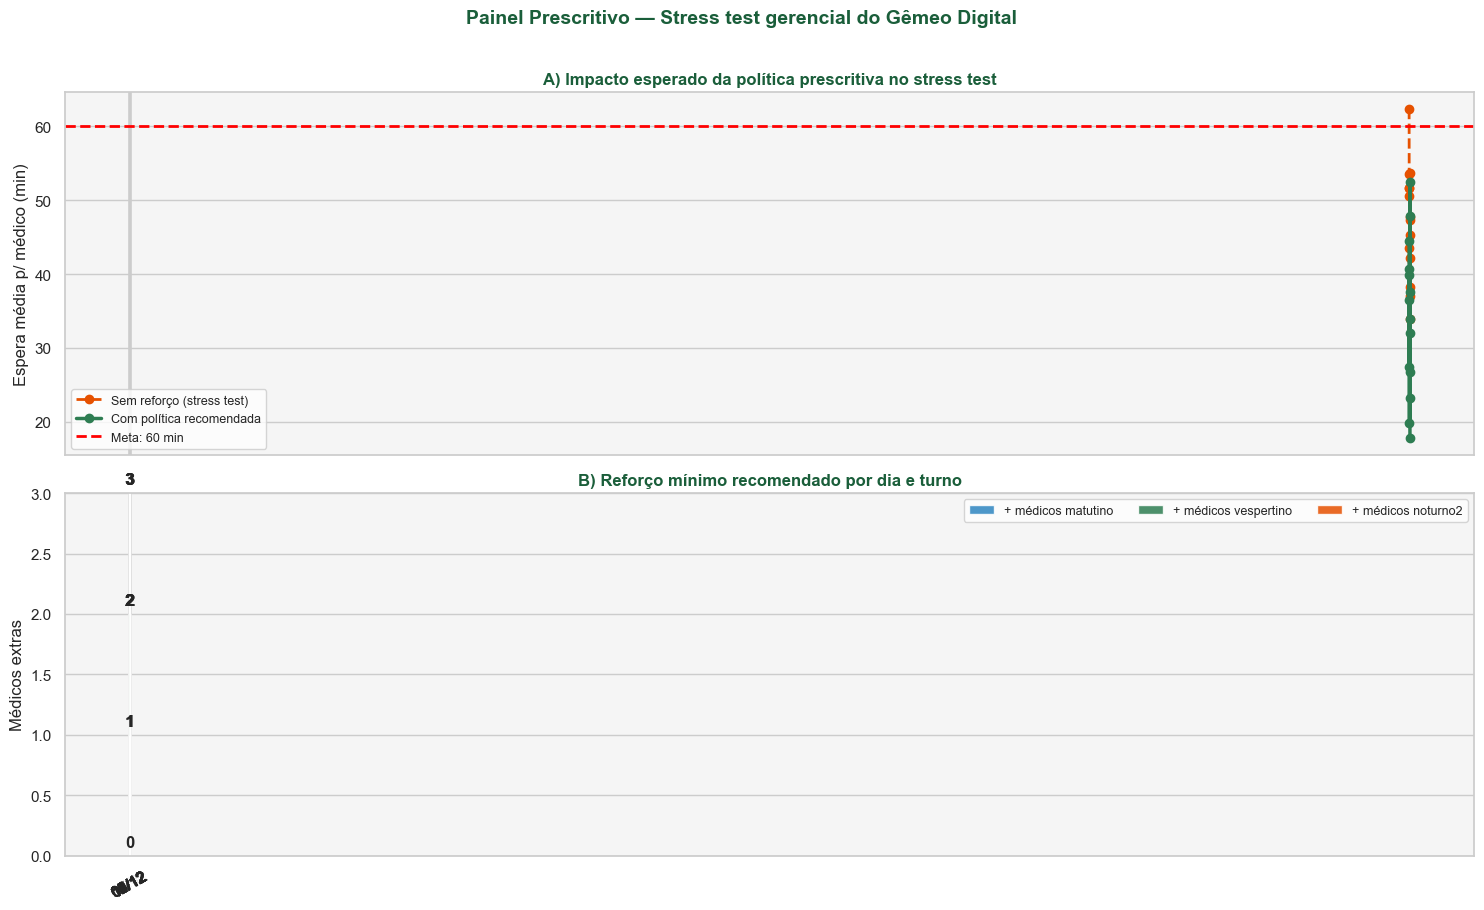

📊  Painel prescritivo gerado — Figura 7


In [80]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 20 — Painel prescritivo do stress test
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax1 = axes[0]
ax1.plot(
    df_plano["ds"],
    df_plano["espera_base"],
    "o--",
    color=LARANJA,
    linewidth=2,
    label="Sem reforço (stress test)",
)
ax1.plot(
    df_plano["ds"],
    df_plano["espera_pos"],
    "o-",
    color=VERDE2,
    linewidth=2.5,
    label="Com política recomendada",
)
ax1.axhline(60, color="red", linestyle="--", linewidth=2, label="Meta: 60 min")
ax1.set_ylabel("Espera média p/ médico (min)")
ax1.set_title(
    "A) Impacto esperado da política prescritiva no stress test",
    fontweight="bold",
    color=VERDE,
)
ax1.legend(fontsize=9)
ax1.set_facecolor(CINZA)

ax2 = axes[1]
x = np.arange(len(df_plano))
ax2.bar(x, df_plano["matutino"], color=AZUL2, alpha=0.85, label="+ médicos matutino")
ax2.bar(
    x,
    df_plano["vespertino"],
    bottom=df_plano["matutino"],
    color=VERDE2,
    alpha=0.85,
    label="+ médicos vespertino",
)
ax2.bar(
    x,
    df_plano["noturno2"],
    bottom=df_plano["matutino"] + df_plano["vespertino"],
    color=LARANJA,
    alpha=0.85,
    label="+ médicos noturno2",
)
for i, total in enumerate(df_plano["extra_total"]):
    ax2.text(
        i, total + 0.05, f"{int(total)}", ha="center", va="bottom", fontweight="bold"
    )
ax2.set_xticks(x)
ax2.set_xticklabels(df_plano["ds"].dt.strftime("%d/%m"), rotation=30)
ax2.set_ylabel("Médicos extras")
ax2.set_title(
    "B) Reforço mínimo recomendado por dia e turno",
    fontweight="bold",
    color=VERDE,
)
ax2.legend(fontsize=9, ncol=3, loc="upper right")
ax2.set_facecolor(CINZA)

fig.suptitle(
    "Painel Prescritivo — Stress test gerencial do Gêmeo Digital",
    fontsize=14,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig7_prescritivo.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Painel prescritivo gerado — Figura 7")

---

## Fechamento — O framework completo percorrido nesta aula

### 🔄 Da leitura do sistema à decisão apoiada por modelo

```
ETAPA 1  Compreender o sistema real
         ↓
ETAPA 2  Transformar dados em parâmetros
         ↓
ETAPA 3  Construir o modelo operacional
         ↓
ETAPA 4  Executar com replicações e IC
         ↓
ETAPA 5  Validar o twin contra a realidade
         ↓
ETAPA 6  Atualizar com novos dados
         ↓
ETAPA 7  Explorar cenários e antecipar demanda
         ↓
ETAPA 8  Prescrever ações sob stress test
```

### ✅ O que esta aula final consolida

| Etapa | Pergunta respondida                 | Entrega principal                                              |
| ----- | ----------------------------------- | -------------------------------------------------------------- |
| 1     | O que o sistema real está dizendo?  | Base histórica do D9 lida como fotografia operacional          |
| 2     | Como o dado vira input do twin?     | `λ(h)`, distribuição de serviço e capacidade por turno         |
| 3     | Como representar o PA no simulador? | Fluxo completo com blocos SimPy já conhecidos                  |
| 4     | Como gerar evidência confiável?     | Replicações, warm-up e IC 95%                                  |
| 5     | O twin é confiável para gestão?     | Checkpoint de validação metodológica                           |
| 6     | Como o twin permanece vivo?         | Pipeline de atualização e detecção de drift                    |
| 7     | O que tende a acontecer à frente?   | Cenários, painel integrado e predição                          |
| 8     | O que fazer diante disso?           | Stress test prescritivo com Pyomo para escolher reforço mínimo |

### 🛑 Status metodológico desta execução

Nesta execução, o status metodológico final do twin depende do último checkpoint de validação/recalibração exibido acima. Use esse checkpoint como referência para decidir se atualização, cenários, predição e prescrição estão em modo gerencial ou apenas ilustrativo.

Ainda assim, a aula percorreu a cadeia completa que interessa ao módulo: **dado histórico → twin → validação → predição → prescrição**.

### 🧠 Leitura gerencial da camada prescritiva

- **Decisão apoiada:** identificar em quais dias e turnos vale pagar reforço para segurar a meta de espera sob stress.
- **Trade-off ativado:** custo adicional de escala versus redução de fila e proteção do nível de serviço.
- **Quando a recomendação mudaria:** se a demanda crítica ficasse mais severa, se a meta fosse endurecida ou se a capacidade base fosse recalibrada para baixo.
- **Por que isso importa no twin:** a camada prescritiva mostra como sair do diagnóstico e chegar à ação, mesmo quando o exemplo atual ainda precisa de recalibração antes do uso real.

> ⚠️ **Lembrete metodológico:** o stress test didático existe para revelar a lógica decisória e tornar o trade-off legível; ele não substitui a validação do twin.

### 📚 Referências

- BANKS, J. et al. _Discrete-Event System Simulation_. 5. ed. Pearson Education, 2010.
- CHWIF, L.; MEDINA, A. C. _Modelagem e Simulação de Eventos Discretos_. 4. ed. Elsevier, 2014.
- D'AGOSTINO, R. B.; STEPHENS, M. A. _Goodness-of-Fit Techniques_. Marcel Dekker, 1986.
- LAW, A. M. _Simulation Modeling and Analysis_. 5. ed. McGraw-Hill, 2015.
- MASSEY, F. J. The Kolmogorov-Smirnov Test for Goodness of Fit. _JASA_, 46(253), 68–78, 1951.
- NELSON, B. L. _Foundations and Methods of Stochastic Simulation_. Springer, 2013.
- SARGENT, R. G. Verification and validation of simulation models. _Journal of Simulation_, 7(1), 12–24, 2013.
- TAYLOR, S. J.; LETHAM, B. Forecasting at scale. _The American Statistician_, 72(1), 37–45, 2018.
- SimPy Developers. _SimPy Documentation_. https://simpy.readthedocs.io (2024)
- Meta Open Source. _Prophet Documentation_. https://facebook.github.io/prophet (2023)

### 📖 Próximos passos sugeridos

- recalibrar `λ(h)`, capacidade efetiva e overheads para elevar a congestão simulada;
- revisar mecanismos que geram fila e cauda de espera no modelo;
- só então reabrir uso gerencial de cenários, previsão e prescrição.
